#   ZOMATO RESTAURANT SUCCESS ANALYSIS
###   "What Makes a Restaurant Succeed in Bangalore, Mumbai & Delhi?"

In [2]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
import os

# This is the only command you need for visuals in Jupyter
%matplotlib inline

In [3]:
#  GLOBAL STYLE  —  defined once, applied everywhere for visual consistency
 
CITY_COLORS = {
    "Bangalore" : "#E63946",
    "Mumbai"    : "#457B9D",
    "Delhi"     : "#2A9D8F",
}
 
plt.rcParams.update({
    "figure.dpi"        : 150,
    "figure.facecolor"  : "#FAFAFA",
    "axes.facecolor"    : "#FAFAFA",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "legend.frameon"    : False,
    "font.family"       : "DejaVu Sans",
})
 
OUT_DIR = "zomato_analysis_outputs"

def save(fig, filename):
    if not os.path.exists(OUT_DIR):
        os.makedirs(OUT_DIR)
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()       # ← show BEFORE closing
    plt.close(fig)   # ← close AFTER showing

    
    # REMOVED plt.close(fig) so you can see it in the notebook!
    print(f"    ✓  Saved successfully to: {path}")

###  CHAPTER 1 — RAW DATA AUDIT

In [5]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv("zomato_dataset.csv")

print(f"\n  Dataset shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


  Dataset shape : 123,657 rows × 12 columns


In [6]:
# ── AUDIT 1: Column Names ─────────────────────────────────────────────────────

print("\n  ── AUDIT 1: Column Names ──────────────────────────────────────────")
print(f"  Raw column list: {df_raw.columns.tolist()}")
 
bad_cols = [c for c in df_raw.columns if c != c.strip()]
print(f"  Columns with leading/trailing whitespace: {bad_cols}")


  ── AUDIT 1: Column Names ──────────────────────────────────────────
  Raw column list: ['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes', 'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name', 'Best Seller', 'Votes', 'Prices']
  Columns with leading/trailing whitespace: ['Cuisine ']


- **Column Name Formatting Issue**  
  The column `'Cuisine '` contains a trailing space, which leads to access errors such as `KeyError` when using `df['Cuisine']`.

- **Impact on Analysis**  
  This issue disrupts all operations involving the column, including grouping and aggregation (e.g., `groupby` on cuisine), resulting in failed or incorrect computations.

- **Recommended Action**  
  Column names should be standardized by removing leading/trailing whitespace to ensure consistent and error-free data operations.

In [12]:
# ── AUDIT 2: City Column ─────────────────────────────────────────────────────
# City is our primary segmentation variable. Errors here affect every analysis.
print("\n  ── AUDIT 2: City Column Values ────────────────────────────────────")
print(f"  All unique city values:\n  {df_raw['City'].unique().tolist()}")
 
print(f"\n  Record counts per city:")
print(df_raw['City'].value_counts().to_string())
 
# Investigate the neighbourhood entries — are they genuinely separate cities?
print(f"\n  Investigating suspicious 'city' entries:")
for nb in [' Banaswadi', ' Ulsoor', ' Magrath Road', ' Malleshwaram']:
    sub = df_raw[df_raw['City'] == nb]
    rest_names = sub['Restaurant Name'].unique()
    print(f"    {nb.strip():15s} → {len(sub):3d} rows, "
          f"unique restaurants: {len(rest_names)}, "
          f"name(s): {list(rest_names)}")


  ── AUDIT 2: City Column Values ────────────────────────────────────
  All unique city values:
  [' Hyderabad', ' Mumbai', ' Chennai', ' Pune', ' Jaipur', ' Kochi', ' Goa', ' Bangalore', ' Kolkata', ' Ahmedabad', ' Banaswadi', ' Ulsoor', ' Malleshwaram', ' Magrath Road', ' Lucknow', ' New Delhi', ' Raipur']

  Record counts per city:
City
Hyderabad       15613
Jaipur          14438
Mumbai          13535
Chennai         13100
Bangalore       12040
Ahmedabad       10178
Kolkata          8662
Pune             8067
Kochi            7759
Raipur           7700
Lucknow          6455
New Delhi        3490
Goa              2360
Banaswadi          97
Ulsoor             66
Magrath Road       54
Malleshwaram       43

  Investigating suspicious 'city' entries:
    Banaswadi       →  97 rows, unique restaurants: 1, name(s): ['GOPIZZA']
    Ulsoor          →  66 rows, unique restaurants: 1, name(s): ['Dum Safar Biryani']
    Magrath Road    →  54 rows, unique restaurants: 1, name(s): ['Keventers I

- **Leading Whitespace in City Names**  
  All entries in the `'City'` column contain a leading space (e.g., `' Mumbai'`, `' Bangalore'`). This causes filtering conditions such as `df[df['City'] == 'Mumbai']` to return zero rows, effectively breaking all city-based queries.

- **Neighbourhoods Misclassified as Cities**  
  Four entries—**Banaswadi**, **Ulsoor**, **Magrath Road**, and **Malleshwaram**—are incorrectly labeled as cities. These are neighbourhoods within Bangalore and should not be treated as separate city-level entities.

- **Inconsistent City Naming**  
  The dataset uses `'New Delhi'` instead of the standardized `'Delhi'`, introducing inconsistency in city naming conventions.

- **Confirmed Misclassification Pattern**  
  Each of the incorrectly labeled “cities” contains exactly one restaurant, confirming that these are isolated misclassifications rather than legitimate city entries.

- **Recommended Action**  
  - Remove leading whitespace from all city names.  
  - Standardize `'New Delhi'` to `'Delhi'`. 

In [15]:
# ── AUDIT 3: Missing Values ───────────────────────────────────────────────────
# Before deciding how to handle nulls, we must understand WHY they exist.
# The right treatment depends entirely on the cause.
print("\n  ── AUDIT 3: Missing Values ────────────────────────────────────────")
null_df = pd.DataFrame({
    "missing_count": df_raw.isnull().sum(),
    "missing_pct"  : (df_raw.isnull().mean() * 100).round(2)
}).query("missing_count > 0")
print(f"\n{null_df.to_string()}")

# Where are the Delivery Rating nulls concentrated?
print(f"\n  Delivery Rating nulls by city:")
delivery_nulls = (df_raw.groupby('City')['Delivery Rating']
                  .apply(lambda x: x.isnull().sum())
                  .loc[lambda x: x > 0])
print(delivery_nulls.to_string())


  ── AUDIT 3: Missing Values ────────────────────────────────────────

                 missing_count  missing_pct
Dining Rating            32236        26.07
Delivery Rating           1280         1.04
Best Seller              95715        77.40

  Delivery Rating nulls by city:
City
Goa          852
Hyderabad     66
Jaipur        83
Kochi         12
Mumbai        99
Pune          25
Raipur       143


- **Missing Values in 'Best Seller' (77.4%)**  
  A significant proportion of the `'Best Seller'` field is missing. This is not a data quality issue; rather, it reflects that most menu items do not have an associated promotional label. Missing values should be interpreted as "no label assigned," representing a valid and meaningful state.

- **Missing Values in 'Dining Rating' (26.1%)**  
  Over a quarter of the entries lack a `'Dining Rating'`. This is expected for delivery-only or cloud kitchen restaurants, which do not offer dine-in services. Imputing these values would introduce artificial data and should be avoided or handled with caution.

- **Missing Values in 'Delivery Rating' (1.04%)**  
  The `'Delivery Rating'` column has a relatively small proportion of missing values. These are likely due to random data collection gaps rather than structural issues. A context-aware imputation strategy can be applied if necessary.

- **Distribution of Missing Values**  
  Missing values are distributed across multiple cities rather than being concentrated in a specific location. This pattern indicates random data gaps rather than a systematic, city-level data quality issue.

In [18]:
# ── AUDIT 4: Data Types ───────────────────────────────────────────────────────
print("\n  ── AUDIT 4: Data Types ────────────────────────────────────────────")
print(f"\n{df_raw.dtypes.to_string()}")


  ── AUDIT 4: Data Types ────────────────────────────────────────────

Restaurant Name     object
Dining Rating      float64
Delivery Rating    float64
Dining Votes         int64
Delivery Votes       int64
Cuisine             object
Place Name          object
City                object
Item Name           object
Best Seller         object
Votes                int64
Prices             float64


- **Data Type Validation**  
  the `'Prices'` column is stored as `float64`, which requires further examination.

- **Next Step Identified**  
  The price distribution will be analyzed to identify potential anomalies or outliers that may justify the use of a floating-point representation.

In [21]:
# ── AUDIT 5: Price Column ─────────────────────────────────────────────────────
# A numeric column can have the right dtype but still have problematic values.
print("\n  ── AUDIT 5: Price Distribution ────────────────────────────────────")
print(f"\n  Descriptive statistics:\n{df_raw['Prices'].describe().round(2).to_string()}")
print(f"\n  Key percentile thresholds:")
print(df_raw['Prices'].quantile([0.90, 0.95, 0.97, 0.99, 1.00]).to_string())


  ── AUDIT 5: Price Distribution ────────────────────────────────────

  Descriptive statistics:
count    123657.00
mean        241.38
std         192.83
min           0.95
25%         130.00
50%         208.57
75%         299.00
max       12024.00

  Key percentile thresholds:
0.90      409.00
0.95      529.66
0.97      630.00
0.99      929.00
1.00    12024.00


- **Unusually Low Minimum Price**  
  The minimum recorded price is ₹0.95, indicating the presence of sub-rupee items. These are likely minor add-ons such as condiments or placeholder entries (e.g., sauce sachets, extra chutney). Including such values in analysis can artificially lower restaurant-level average prices.

- **Extreme High-Value Outliers**  
  The maximum price reaches ₹12,024, while the 99th percentile (p99) is ₹929. This highlights the presence of extreme outliers within the top 1% of the dataset, likely representing bulk orders, catering platters, or event packages.

- **Impact on Aggregations**  
  These high-value outliers can significantly distort aggregate metrics, particularly average price calculations at the restaurant level.

- **Recommended Approach**
  Instead of applying a single global cutoff, a city-wise capping strategy is recommended to more accurately handle pricing variations across different markets.

In [24]:
# ── AUDIT 6: Duplicate Records ────────────────────────────────────────────────
# Duplicates are not all the same. We must identify what KIND of duplication
# exists before deciding how to handle it.
print("\n  ── AUDIT 6: Duplicate Records ─────────────────────────────────────")
 
full_dupe_count    = df_raw.duplicated().sum()
item_city_dupe_count = df_raw.duplicated(
    subset=['Restaurant Name', 'Item Name', 'City']
).sum()
 
print(f"\n  Fully identical rows (every column matches) : {full_dupe_count:,}")
print(f"  Same Restaurant + Item + City (any column may differ): {item_city_dupe_count:,}")
print(f"  Gap between the two counts                  : "
      f"{item_city_dupe_count - full_dupe_count:,} rows")
 
# The gap of ~5,500 means some rows share the same restaurant/item/city
# but DIFFER in at least one other column. What column differs?
partial_mask = df_raw.duplicated(
    subset=['Restaurant Name', 'Item Name', 'City'], keep=False
)
full_mask = df_raw.duplicated(keep=False)
type2_rows = df_raw[partial_mask & ~full_mask]
 
print(f"\n  Investigating the {len(type2_rows):,} rows that differ in some column...")
print(f"  Picking one restaurant to examine in detail:")
 
# Show exactly what differs for a concrete example
example = df_raw[
    (df_raw['Restaurant Name'] == '12 To 12 BBQ') &
    (df_raw['Item Name']       == 'Pakistani Biryani')
][['Restaurant Name', 'Item Name', 'City', 'Prices', 'Votes', 'Best Seller']]
print(f"\n  Example — 'Pakistani Biryani' at '12 To 12 BBQ':")
print(example.to_string(index=False))
 
example2 = df_raw[
    (df_raw['Restaurant Name'] == '12 To 12 BBQ') &
    (df_raw['Item Name']       == 'Kebab Biryani')
][['Restaurant Name', 'Item Name', 'City', 'Prices', 'Votes', 'Best Seller']]
print(f"\n  Example — 'Kebab Biryani' at '12 To 12 BBQ':")
print(example2.to_string(index=False))
  
print(f"\n  ► AUDIT FINDING: Two types of duplicates identified:")
print(f"    Type 1 — Fully identical rows (scraper artifact) : {full_dupe_count:,} to remove")
print(f"    Type 2 — Same item, different Best Seller tag    : ~{item_city_dupe_count - full_dupe_count:,} to deduplicate")


  ── AUDIT 6: Duplicate Records ─────────────────────────────────────

  Fully identical rows (every column matches) : 22,127
  Same Restaurant + Item + City (any column may differ): 27,651
  Gap between the two counts                  : 5,524 rows

  Investigating the 9,990 rows that differ in some column...
  Picking one restaurant to examine in detail:

  Example — 'Pakistani Biryani' at '12 To 12 BBQ':
Restaurant Name         Item Name   City  Prices  Votes Best Seller
   12 To 12 BBQ Pakistani Biryani  Kochi   315.0     91    MUST TRY
   12 To 12 BBQ Pakistani Biryani  Kochi   315.0     91  BESTSELLER

  Example — 'Kebab Biryani' at '12 To 12 BBQ':
Restaurant Name     Item Name   City  Prices  Votes Best Seller
   12 To 12 BBQ Kebab Biryani  Kochi   315.0     25    MUST TRY
   12 To 12 BBQ Kebab Biryani  Kochi   315.0     25  BESTSELLER

  ► AUDIT FINDING: Two types of duplicates identified:
    Type 1 — Fully identical rows (scraper artifact) : 22,127 to remove
    Type 2 — Same

- **Two Distinct Types of Duplicate Records Identified**

  **Type 1 — Fully Identical Rows (22,127 records)**  
  These rows are exact duplicates across all columns, including item name, price, votes, and promotional tags. This issue originates from the data collection process, where the scraper likely revisited and captured the same pages multiple times.  
  **Impact:** Inflates counts and biases all aggregate metrics.  
  **Recommended Action:** Remove using `drop_duplicates()` to ensure data integrity.

  **Type 2 — Same Item with Different Promotional Tags (~5,500 records)**  
  Certain items (e.g., *Pakistani Biryani*) appear multiple times with identical attributes (price, votes, etc.) but different `'Best Seller'` tags such as *'MUST TRY'* and *'BESTSELLER'*.  
  **Root Cause:** This is a data collection artifact arising from the source platform, where a single item may be featured under multiple promotional sections (e.g., “Must Try” and “Bestseller”). The scraper captured each occurrence separately, resulting in duplicated rows.

  **Critical Insight**  
  These entries do not represent distinct menu items. Each item exists only once, with a single price and vote count. Retaining multiple rows would lead to double-counting in analyses, distorting key metrics.

  **Recommended Action**  
  Implement a priority-based deduplication strategy:
  - Retain the row with the highest-priority promotional tag  
    *(BESTSELLER > MUST TRY > CHEF'S SPECIAL > others > NaN)*  
  - Remove the remaining duplicates after prioritization  

  This approach preserves the strongest demand signal while preventing artificial inflation of menu data.

In [27]:
# ── AUDIT 7: Best Seller Column Values ────────────────────────────────────────
print("\n  ── AUDIT 7: Best Seller Column ────────────────────────────────────")
print(f"\n  All tag values and their frequency:")
print(df_raw['Best Seller'].value_counts().to_string())


  ── AUDIT 7: Best Seller Column ────────────────────────────────────

  All tag values and their frequency:
Best Seller
BESTSELLER                  16992
MUST TRY                     4151
Not eligible for coupons     2440
CHEF'S SPECIAL               1822
SPICY                        1254
Not on Pro                    657
NEW                           455
SEASONAL                       91
Eggless available              34
VEGAN                          26
GLUTEN FREE                     9
FODMAP FRIENDLY                 9
DAIRY FREE                      2


- **Mixed Semantics in a Single Column**  
  The column combines two fundamentally different categories of information:

  - **Demand / Quality Signals**  
    Tags such as *BESTSELLER*, *MUST TRY*, and *CHEF'S SPECIAL* indicate item popularity or recommendation strength. These are directly relevant for measuring item success and customer preference.

  - **Attribute / Business Tags**  
    Labels such as *VEGAN*, *GLUTEN FREE*, *SPICY*, *Not on Pro*, *NEW*, and *SEASONAL* describe item characteristics or business rules. These do not reflect demand or performance.

- **Impact on Feature Engineering**  
  Treating both categories as a single variable would result in a semantically inconsistent and analytically weak feature, mixing demand signals with descriptive attributes.

In [30]:
# ── AUDIT 8: Rating Ranges ────────────────────────────────────────────────────
print("\n  ── AUDIT 8: Rating Ranges ─────────────────────────────────────────")
for col in ['Delivery Rating', 'Dining Rating']:
    s = df_raw[col].dropna()
    print(f"  {col:20s}: min={s.min()}, max={s.max()}, "
          f"mean={s.mean():.2f}, nulls={df_raw[col].isnull().sum()}")


  ── AUDIT 8: Rating Ranges ─────────────────────────────────────────
  Delivery Rating     : min=2.5, max=4.6, mean=3.96, nulls=1280
  Dining Rating       : min=2.5, max=4.8, mean=3.82, nulls=32236


- **Validation of Rating Values**  
  Both rating columns fall within a realistic and expected range of 2.5 to 4.8.

- **No Invalid Entries Detected**  
  There are no impossible values such as negative ratings or values exceeding the maximum scale (e.g., above 5).

- **Conclusion**  
  The rating data is clean and does not require correction or filtering based on value range.

In [33]:
# ── AUDIT SUMMARY ─────────────────────────────────────────────────────────────
print("\n" + "-"*70)
print("  AUDIT COMPLETE — Confirmed Issues:")
print("  Issue 1 : 'Cuisine ' has a trailing space in the column name")
print("  Issue 2 : All City values have a leading whitespace character")
print("  Issue 3 : 4 'city' values are Bangalore neighbourhoods, not cities")
print("  Issue 4 : 'New Delhi' used — should be standardised to 'Delhi'")
print("  Issue 5a: 22,127 fully identical rows — scraper artifact, safe to drop")
print("  Issue 5b: ~5,500 rows — same item, different Best Seller tag — need")
print("            priority-based deduplication to preserve the best signal")
print("  Issue 6 : 'Dining Rating' — 26.1% missing (delivery-only restaurants)")
print("  Issue 7 : 'Delivery Rating' — 1.0% missing (random collection gaps)")
print("  Issue 8 : 'Best Seller' mixes demand signals with attribute tags")
print("  Issue 9 : Price outliers — sub-₹5 items and top-1% city prices skew averages")
print("-"*70)


----------------------------------------------------------------------
  AUDIT COMPLETE — Confirmed Issues:
  Issue 1 : 'Cuisine ' has a trailing space in the column name
  Issue 2 : All City values have a leading whitespace character
  Issue 3 : 4 'city' values are Bangalore neighbourhoods, not cities
  Issue 4 : 'New Delhi' used — should be standardised to 'Delhi'
  Issue 5a: 22,127 fully identical rows — scraper artifact, safe to drop
  Issue 5b: ~5,500 rows — same item, different Best Seller tag — need
            priority-based deduplication to preserve the best signal
  Issue 6 : 'Dining Rating' — 26.1% missing (delivery-only restaurants)
  Issue 7 : 'Delivery Rating' — 1.0% missing (random collection gaps)
  Issue 8 : 'Best Seller' mixes demand signals with attribute tags
  Issue 9 : Price outliers — sub-₹5 items and top-1% city prices skew averages
----------------------------------------------------------------------


###  CHAPTER 2 — DATA CLEANING

In [36]:
df = df_raw.copy()   # Never modify raw data — always work on a copy

In [38]:
# ── FIX 1: Strip whitespace from column names  (→ Issue 1) ───────────────────
print("\n  [Fix 1] Stripping whitespace from column names...")
print(f"    Before : {df.columns.tolist()}")
df.columns = df.columns.str.strip()
print(f"    After  : {df.columns.tolist()}")


  [Fix 1] Stripping whitespace from column names...
    Before : ['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes', 'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name', 'Best Seller', 'Votes', 'Prices']
    After  : ['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes', 'Delivery Votes', 'Cuisine', 'Place Name', 'City', 'Item Name', 'Best Seller', 'Votes', 'Prices']


- **Column Name Standardization**  
  The column `'Cuisine '` has been successfully renamed to `'Cuisine'` by removing the trailing whitespace.

In [41]:
# ── FIX 2: Strip whitespace from all string values  (→ Issue 2) ──────────────
print("\n  [Fix 2] Stripping leading/trailing spaces from all string values...")
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()
clean_cities = sorted(df['City'].unique().tolist())
print(f"    City values after strip: {clean_cities}")


  [Fix 2] Stripping leading/trailing spaces from all string values...
    City values after strip: ['Ahmedabad', 'Banaswadi', 'Bangalore', 'Chennai', 'Goa', 'Hyderabad', 'Jaipur', 'Kochi', 'Kolkata', 'Lucknow', 'Magrath Road', 'Malleshwaram', 'Mumbai', 'New Delhi', 'Pune', 'Raipur', 'Ulsoor']


- **City Name Standardization**  
  The value `' Mumbai'` has been corrected to `'Mumbai'` by removing the leading whitespace.

- **Impact**  
  This ensures that city-based filtering operations (e.g., `df[df['City'] == 'Mumbai']`) now return accurate results and function as expected.

In [44]:
# ── FIX 3: Remap Bangalore neighbourhoods  (→ Issue 3) ───────────────────────
print("\n  [Fix 3] Remapping Bangalore neighbourhood entries to 'Bangalore'...")
bangalore_suburbs = ["Banaswadi", "Ulsoor", "Magrath Road", "Malleshwaram"]
rows_before = df['City'].isin(bangalore_suburbs).sum()
df['City'] = df['City'].replace({nb: "Bangalore" for nb in bangalore_suburbs})
print(f"    {rows_before} rows remapped to 'Bangalore'.")


  [Fix 3] Remapping Bangalore neighbourhood entries to 'Bangalore'...
    260 rows remapped to 'Bangalore'.


- **Reclassification of Misassigned Entries**  
  The identified records correspond to restaurants located in Bangalore but were previously misclassified under incorrect city labels.

In [47]:
# ── FIX 4: Standardise 'New Delhi' → 'Delhi'  (→ Issue 4) ───────────────────
print("\n  [Fix 4] Standardising 'New Delhi' → 'Delhi'...")
df['City'] = df['City'].replace({"New Delhi": "Delhi"})
print(f"    City values now: {sorted(df['City'].unique().tolist())}")


  [Fix 4] Standardising 'New Delhi' → 'Delhi'...
    City values now: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Pune', 'Raipur']


In [49]:
# ── FIX 5: Remove duplicate rows — two-stage process  (→ Issue 5a & 5b) ──────
print("\n  [Fix 5] Removing duplicates — two-stage process...")
 
# Stage A: Best Seller priority resolution (handles Issue 5b first)
# ─────────────────────────────────────────────────────────────────
# Before dropping any rows, we resolve the Type 2 duplicates intelligently.
# When the same item appears with multiple Best Seller tags, we keep the row
# that carries the STRONGEST demand signal (priority order below).
# Why priority order instead of just dropping? Because losing 'BESTSELLER'
# in favour of NaN for the same item would undercount promoted items — directly
# affecting our bestseller analysis in Chapter 4.
TAG_PRIORITY = {
    "BESTSELLER"    : 1,
    "MUST TRY"      : 2,
    "CHEF'S SPECIAL": 3,
    "SPICY"         : 4,
    "NEW"           : 5,
    "SEASONAL"      : 6,
}
df['tag_rank'] = df['Best Seller'].map(TAG_PRIORITY).fillna(99)
 
# Sort so that for each Restaurant+Item+City group, the best tag comes first
df = df.sort_values(
    ['Restaurant Name', 'Item Name', 'City', 'tag_rank'],
    ascending=[True, True, True, True]
)
 
# Stage B: Drop all remaining duplicates (handles both Type 1 and the now-sorted Type 2)
rows_before = len(df)
df = df.drop_duplicates(subset=['Restaurant Name', 'Item Name', 'City'], keep='first')
rows_removed = rows_before - len(df)
print(f"    Rows before deduplication : {rows_before:,}")
print(f"    Rows removed              : {rows_removed:,}")
print(f"    Rows remaining            : {len(df):,}")
 
# Clean up the helper column — no longer needed
df = df.drop(columns=['tag_rank'])


  [Fix 5] Removing duplicates — two-stage process...
    Rows before deduplication : 123,657
    Rows removed              : 27,651
    Rows remaining            : 96,006


In [50]:
# ── FIX 6: Filter to the three target cities ─────────────────────────────────
# Business reason: Our research question is about Bangalore, Mumbai, and Delhi.
# A focused analysis on three comparable metro cities is more rigorous than a
# 13-city average that mixes metros with smaller cities like Raipur or Goa.
print("\n  [Fix 6] Filtering to three target cities: Bangalore, Mumbai, Delhi...")
before = len(df)
TARGET = ["Bangalore", "Mumbai", "Delhi"]
df = df[df['City'].isin(TARGET)].copy()
print(f"    Rows before: {before:,}  →  Rows after: {len(df):,}")


  [Fix 6] Filtering to three target cities: Bangalore, Mumbai, Delhi...
    Rows before: 96,006  →  Rows after: 22,783


In [53]:
# ── FIX 7: Handle 'Dining Rating' missing values  (→ Issue 6) ────────────────
# Decision: Flag, do not impute, do not drop.
#
# Why NOT impute?
#   A delivery-only restaurant genuinely has no dine-in rating.
#   Assigning it the city average would create a rating that never existed.
#   That is not gap-filling — that is fabrication.
#
# Why NOT drop?
#   Delivery-only restaurants (cloud kitchens) are a major and growing category.
#   Dropping them would systematically remove a class of business that is
#   central to the food-delivery story we are trying to tell.
#
# Solution: Add a boolean flag. Use Delivery Rating as our primary success metric.
print("\n  [Fix 7] Handling missing Dining Ratings...")
print(f"    Missing before: {df['Dining Rating'].isnull().sum():,}")
df['has_dining_rating'] = df['Dining Rating'].notna().astype(int)
df['Dining Rating'] = df['Dining Rating'].fillna(-1)  # -1 = sentinel for "no dine-in"
print(f"    Restaurants with dine-in rating    : {df['has_dining_rating'].sum():,}")
print(f"    Restaurants without (delivery-only): {(df['has_dining_rating']==0).sum():,}")


  [Fix 7] Handling missing Dining Ratings...
    Missing before: 7,632
    Restaurants with dine-in rating    : 15,151
    Restaurants without (delivery-only): 7,632


In [55]:
# ── FIX 8: Fill 'Delivery Rating' missing values  (→ Issue 7) ────────────────
# Strategy: Fill with City × Cuisine median (granular, context-aware).
# Why not global mean? A biryani restaurant in Mumbai has a different rating
# benchmark than a pizza chain in Delhi. Using a group-level median respects that.
# Fallback: City median for cuisine-city combos where no median can be computed.
print("\n  [Fix 8] Filling missing Delivery Ratings with City×Cuisine median...")
print(f"    Missing before: {df['Delivery Rating'].isnull().sum()}")
city_cuisine_med = df.groupby(['City','Cuisine'])['Delivery Rating'].transform('median')
df['Delivery Rating'] = df['Delivery Rating'].fillna(city_cuisine_med)
city_med = df.groupby('City')['Delivery Rating'].transform('median')
df['Delivery Rating'] = df['Delivery Rating'].fillna(city_med)
print(f"    Missing after : {df['Delivery Rating'].isnull().sum()}")


  [Fix 8] Filling missing Delivery Ratings with City×Cuisine median...
    Missing before: 90
    Missing after : 0


In [57]:
# ── FIX 9: Binary-encode 'Best Seller'  (→ Issue 8) ──────────────────────────
# We create a single feature: is this item being actively promoted as a demand signal?
# We include only BESTSELLER, MUST TRY, CHEF'S SPECIAL — the tags that signal
# "customers should order this." All other tags (VEGAN, SPICY, etc.) are attributes,
# not demand signals, and are excluded from this feature.
print("\n  [Fix 9] Binary-encoding 'Best Seller' into demand-signal flag...")
DEMAND_TAGS = ["BESTSELLER", "MUST TRY", "CHEF'S SPECIAL"]
df['is_promoted'] = df['Best Seller'].isin(DEMAND_TAGS).astype(int)
print(f"    Items with demand-signal tag (promoted): {df['is_promoted'].sum():,}")
print(f"    Items without (regular)                : {(df['is_promoted']==0).sum():,}")


  [Fix 9] Binary-encoding 'Best Seller' into demand-signal flag...
    Items with demand-signal tag (promoted): 2,955
    Items without (regular)                : 19,828


In [59]:
# ── FIX 10: Handle price outliers  (→ Issue 9) ────────────────────────────────
# Two-sided treatment:
#   Low end  — remove items priced below ₹5 (condiments, placeholder entries)
#   High end — cap at 99th percentile WITHIN each city
#
# Why per-city cap instead of a global threshold?
#   Mumbai's premium restaurant segment is legitimately more expensive than Delhi's.
#   Per-city capping respects each city's actual price distribution.
print("\n  [Fix 10] Removing price outliers...")
before = len(df)
p99 = df.groupby('City')['Prices'].transform(lambda x: x.quantile(0.99))
df  = df[(df['Prices'] >= 5) & (df['Prices'] <= p99)].copy()
print(f"    Rows removed (price outliers/noise): {before - len(df):,}")
print(f"    Price range after cleaning: "
      f"₹{df['Prices'].min():.0f} – ₹{df['Prices'].max():.0f}")


  [Fix 10] Removing price outliers...
    Rows removed (price outliers/noise): 236
    Price range after cleaning: ₹5 – ₹1099


In [61]:
# ── AGGREGATE: Item level → Restaurant level ───────────────────────────────────
# The raw data is one row per MENU ITEM.
# Our research question is about RESTAURANTS — not individual menu items.
#
# Aggregation decisions explained:
#   avg_price       : mean item price → represents typical spend at this restaurant
#   median_price    : median item price → robust to a few very cheap or expensive items
#   delivery_rating : mean — ratings repeat per item, so mean = restaurant's rating
#   dining_rating   : mean of only valid values (exclude -1 sentinel)
#   delivery_votes  : mean — votes also repeat per item in this dataset
#   total_items     : count → menu breadth proxy
#   promoted_items  : sum → how many items are highlighted as bestsellers/must-try
print("\n  [Aggregate] Rolling up from item level to restaurant level...")
 
rest = (
    df.groupby(['Restaurant Name', 'City', 'Cuisine'])
      .agg(
          avg_price       = ('Prices',          'mean'),
          median_price    = ('Prices',          'median'),
          delivery_rating = ('Delivery Rating', 'mean'),
          dining_rating   = ('Dining Rating',   lambda x: x[x > 0].mean()),
          delivery_votes  = ('Delivery Votes',  'mean'),
          dining_votes    = ('Dining Votes',    'mean'),
          total_items     = ('Item Name',       'count'),
          promoted_items  = ('is_promoted',     'sum'),
          has_dining      = ('has_dining_rating','max'),
      )
      .reset_index()
)
 
# Derived features
rest['promo_ratio'] = rest['promoted_items'] / rest['total_items']
# Engagement: weighted composite of delivery and dining votes.
# Delivery receives higher weight (0.6) because our study context is food delivery.
rest['engagement']  = 0.6 * rest['delivery_votes'] + 0.4 * rest['dining_votes']


  [Aggregate] Rolling up from item level to restaurant level...


In [63]:
# ── SUCCESS DEFINITION ────────────────────────────────────────────────────────
#
# What does "successful" mean for a restaurant on Zomato?
#
# We considered three options:
#
# Option A — Rating only:
#   A ghost kitchen with 3 orders but 4.5 stars qualifies. That is not
#   business success — it is a small sample size artifact. REJECTED.
#
# Option B — Votes/popularity only:
#   A restaurant with thousands of orders but a 3.5 rating qualifies.
#   High demand for a low-quality product is not sustainable. REJECTED.
#
# Option C — Dual condition (chosen):
#   Condition 1: Delivery rating ≥ 4.0
#     Zomato's own interface highlights 4.0+ as "good". Below this threshold,
#     the restaurant appears in search results with a warning colour.
#   Condition 2: Engagement in the top 40% OF THAT CITY (city-relative)
#     Why city-relative? Mumbai's absolute vote volumes are much higher than
#     Delhi's simply because it has a larger Zomato user base. Comparing a
#     Delhi restaurant's vote count against Mumbai's average is unfair.
#     City-relative percentile ensures we identify restaurants that are
#     popular relative to their own competitive landscape.
#
# Both conditions must be met simultaneously. A restaurant that is
# highly rated but nobody orders from, or very popular but consistently rated
# below 4.0 — neither of those qualifies as genuinely successful.
 
print("\n  [Success] Defining the success metric...")
city_engagement_60th = rest.groupby('City')['engagement'].transform(
    lambda x: x.quantile(0.60)   # top 40% = above the 60th percentile
)
rest['is_successful'] = (
    (rest['delivery_rating'] >= 4.0) &
    (rest['engagement']      >= city_engagement_60th)
).astype(int)
 
print(f"\n  Restaurant-level table: {rest.shape[0]} restaurants across 3 cities")
print(f"\n  Success rate by city:")
summary = (rest.groupby('City')['is_successful']
               .agg(successful='sum', total='count')
               .assign(rate=lambda x: (x['successful']/x['total']*100).round(1)))
print(summary.to_string())
 
print(f"\n  ✅  Cleaning complete.")
print(f"      Item-level rows : {len(df):,}")
print(f"      Restaurant rows : {len(rest):,}")


  [Success] Defining the success metric...

  Restaurant-level table: 190 restaurants across 3 cities

  Success rate by city:
           successful  total  rate
City                              
Bangalore          18     86  20.9
Delhi               4     24  16.7
Mumbai             19     80  23.8

  ✅  Cleaning complete.
      Item-level rows : 22,547
      Restaurant rows : 190


###  CHAPTER 3 — EXPLORATORY DATA ANALYSIS

In [66]:
CITIES = ["Bangalore", "Mumbai", "Delhi"]
COLORS = [CITY_COLORS[c] for c in CITIES]
city_rest = {c: rest[rest['City'] == c] for c in CITIES}


 [EDA-1] Building city overview chart...


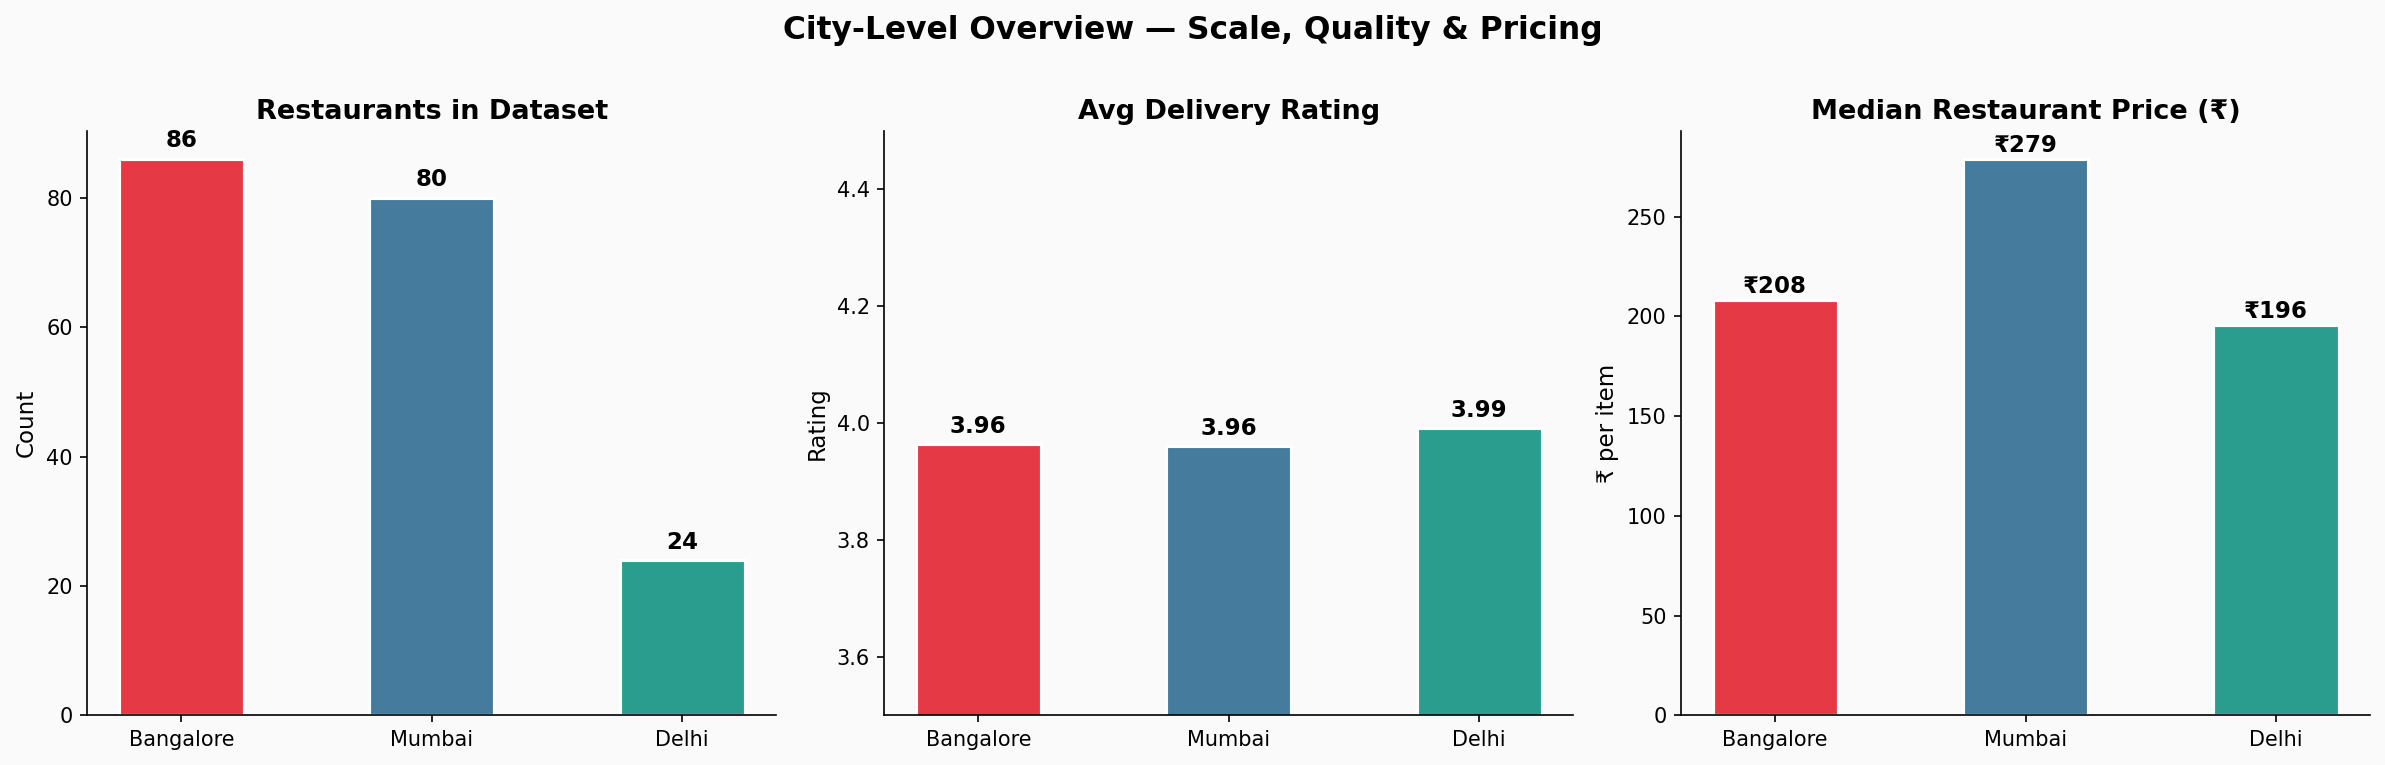

    ✓  Saved successfully to: zomato_analysis_outputs\EDA1_city_overview.png


In [68]:
# EDA Chart 1 — City Overview
# Question: What are we working with? Scale, ratings, pricing at a glance.
# ─────────────────────────────────────────────────────────────────────────────
print("\n [EDA-1] Building city overview chart...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("City-Level Overview — Scale, Quality & Pricing", 
             fontsize=15, fontweight="bold", y=1.01)

# (a) Restaurant count per city
counts = [len(city_rest[c]) for c in CITIES]  # Changed city_data -> city_rest
bars = axes[0].bar(CITIES, counts, color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Restaurants in Dataset")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}", ha="center", va="bottom", fontweight="bold", fontsize=11)

# (b) Average delivery rating per city
avg_rtg = [city_rest[c]['delivery_rating'].mean() for c in CITIES] # Changed city_data -> city_rest
bars2 = axes[1].bar(CITIES, avg_rtg, color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
axes[1].set_title("Avg Delivery Rating")
axes[1].set_ylabel("Rating")
axes[1].set_ylim(3.5, 4.5)
for bar, val in zip(bars2, avg_rtg):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

# (c) Median item price per city
med_prices = [city_rest[c]['median_price'].median() for c in CITIES] # Changed city_data -> city_rest
bars3 = axes[2].bar(CITIES, med_prices, color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
axes[2].set_title("Median Restaurant Price (₹)")
axes[2].set_ylabel("₹ per item")
for bar, val in zip(bars3, med_prices):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"₹{val:.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.tight_layout()
save(fig, "EDA1_city_overview.png")



## 1. Market Size

- Bangalore: 86 restaurants  
- Mumbai: 80 restaurants  
- Delhi: 24 restaurants  

**Observation:**  
Bangalore and Mumbai represent the largest markets in the dataset, with comparable scale. Delhi has a significantly smaller representation, indicating either a smaller market size or limited dataset coverage.

---

## 2. Delivery Quality (Average Rating)

- Bangalore: 3.96  
- Mumbai: 3.96  
- Delhi: 3.99  

**Observation:**  
Average delivery ratings are nearly identical across all cities, with values centered around 4.0. The marginally higher rating in Delhi is not substantial enough to indicate a meaningful difference in service quality.

---

## 3. Pricing (Median Cost per Item)

- Mumbai: ₹279  
- Bangalore: ₹208  
- Delhi: ₹196  

**Observation:**  
Mumbai has the highest median pricing, indicating a more premium market. Bangalore occupies a middle position, while Delhi represents the most affordable pricing structure among the three cities.

---

## 4. Integrated Analysis

### Scale vs Pricing
- Mumbai combines high scale with high pricing, suggesting a premium and competitive market.
- Bangalore demonstrates high scale with moderate pricing, reflecting a balanced ecosystem.
- Delhi shows lower scale and lower pricing, indicating a more budget-oriented market.

---

### Quality vs Pricing
Despite noticeable differences in pricing, delivery ratings remain consistent across cities. This suggests that higher pricing does not necessarily correspond to higher customer satisfaction.

---

## 5. Key Takeaways

- Market size and pricing vary significantly across cities.
- Delivery quality remains consistent, with average ratings around 4.0.
- Mumbai is positioned as a premium market with higher pricing.
- Bangalore offers a balanced combination of scale and affordability.
- Delhi emphasizes affordability with a smaller market footprint.

---

  [EDA-2] Rating distributions + statistical test...


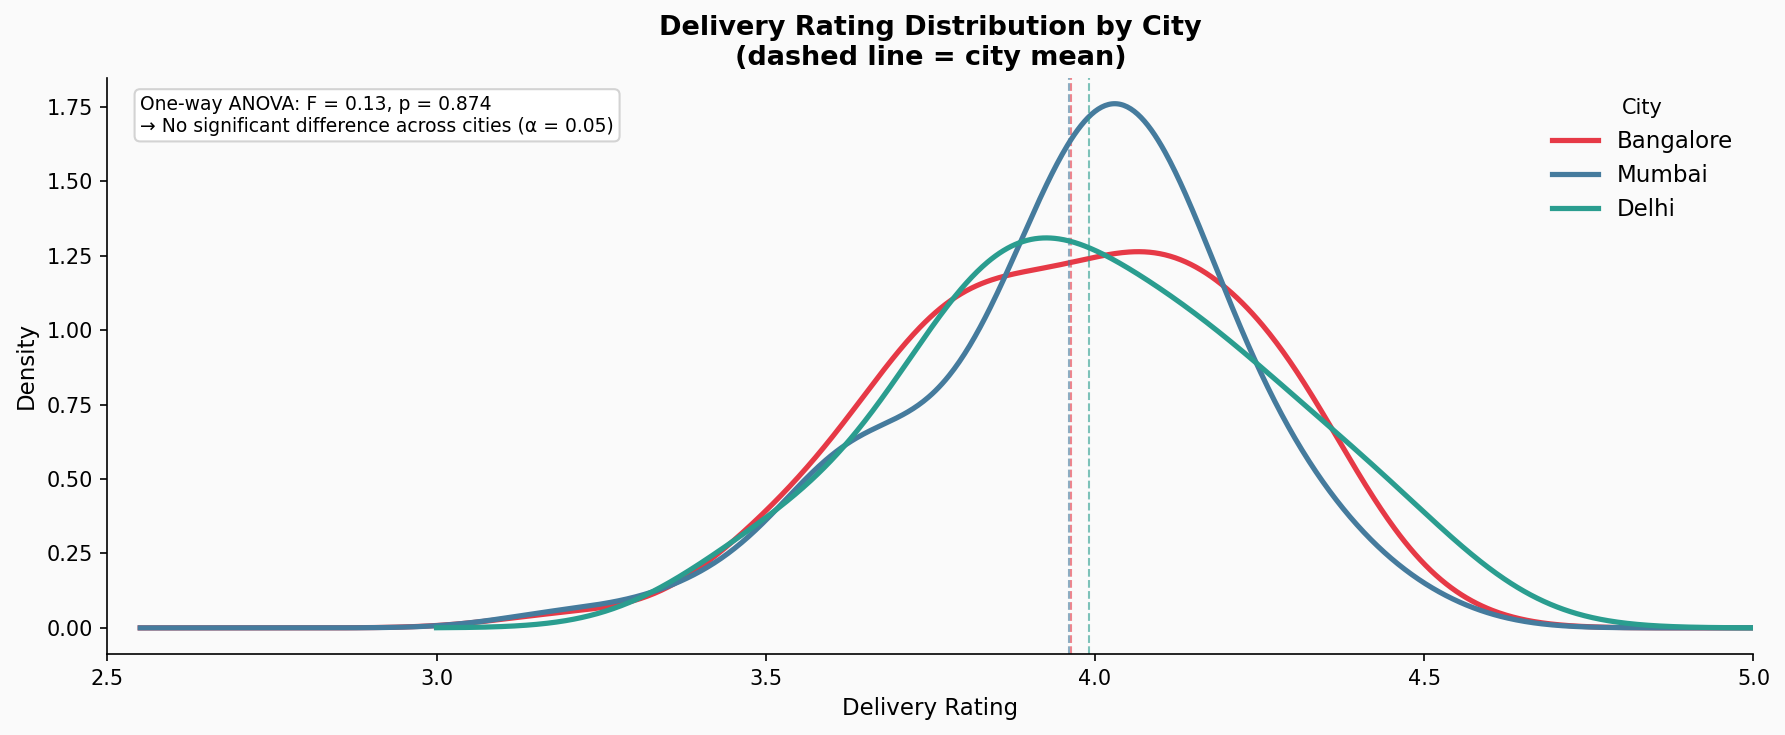

    ✓  Saved successfully to: zomato_analysis_outputs\EDA2_rating_distributions.png
    ANOVA: F=0.13, p=0.874 → No significant difference


In [70]:
# ── EDA Chart 2: Rating Distributions ─────────────────────────────────────────
# Question: Are the three cities' rating profiles meaningfully different?
# Why this matters: If ratings don't differ by city, then rating alone cannot
# explain city-specific success — we need to look at other variables.
print("  [EDA-2] Rating distributions + statistical test...")
 
fig, ax = plt.subplots(figsize=(12, 5))
for city in CITIES:
    data = city_rest[city]['delivery_rating'].dropna()
    data.plot.kde(ax=ax, color=CITY_COLORS[city], linewidth=2.5, label=city)
    ax.axvline(data.mean(), color=CITY_COLORS[city], linestyle="--",
               alpha=0.6, linewidth=1)
 
# ANOVA test: are the city-level rating distributions statistically different?
# We use one-way ANOVA because: 3 groups, continuous outcome, test of means.
f_stat, p_val = stats.f_oneway(
    *[city_rest[c]['delivery_rating'].dropna() for c in CITIES]
)
conclusion = "Significant difference" if p_val < 0.05 else "No significant difference"
ax.text(0.02, 0.97,
        f"One-way ANOVA: F = {f_stat:.2f}, p = {p_val:.3f}\n→ {conclusion} across cities (α = 0.05)",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray"))
 
ax.set_title("Delivery Rating Distribution by City\n(dashed line = city mean)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Delivery Rating")
ax.set_ylabel("Density")
ax.legend(title="City", fontsize=11)
ax.set_xlim(2.5, 5.0)
plt.tight_layout()
save(fig, "EDA2_rating_distributions.png")
print(f"    ANOVA: F={f_stat:.2f}, p={p_val:.3f} → {conclusion}")
# Analyst note: If no significant difference, this is an important finding —
# it means success in these cities CANNOT be explained by rating alone.
# We must look at price positioning, cuisine mix, and menu strategy.

## Key Observations

### Overall Distribution
- Delivery ratings across all cities are concentrated within the 3.5 to 4.5 range.
- The peak density for each city is centered around a rating of approximately 4.0.

**Observation:**  
Customer satisfaction levels are consistently high across all three cities, with minimal variation in rating distributions.

---

### Mean Ratings
- Bangalore: approximately 3.95  
- Mumbai: approximately 4.00  
- Delhi: approximately 4.00  

**Observation:**  
The mean ratings are nearly identical, indicating a uniform level of delivery service quality.

---

### Distribution Characteristics
- Mumbai shows a slightly sharper peak, suggesting more consistent ratings.
- Delhi exhibits a marginally wider spread, indicating slightly higher variability.
- Bangalore presents a balanced distribution.

**Observation:**  
While minor differences in distribution shape exist, they are not substantial.

---

## 2. Statistical Analysis

A one-way ANOVA test was conducted to determine whether differences in mean delivery ratings across cities are statistically significant.

- F-statistic: 0.13  
- p-value: 0.874  

**Interpretation:**  
Since the p-value is significantly greater than the significance level (α = 0.05), there is no statistically significant difference in delivery ratings across the three cities.

---

## 3. Key Takeaways

- Delivery ratings are consistently high across all cities, centered around a rating of 4.0.
- No city demonstrates a statistically significant advantage in delivery performance.
- Variations in cuisine distribution or pricing do not appear to impact delivery ratings.
- The results suggest a standardized level of service quality across urban markets.

---

  [EDA-3] Price distributions...


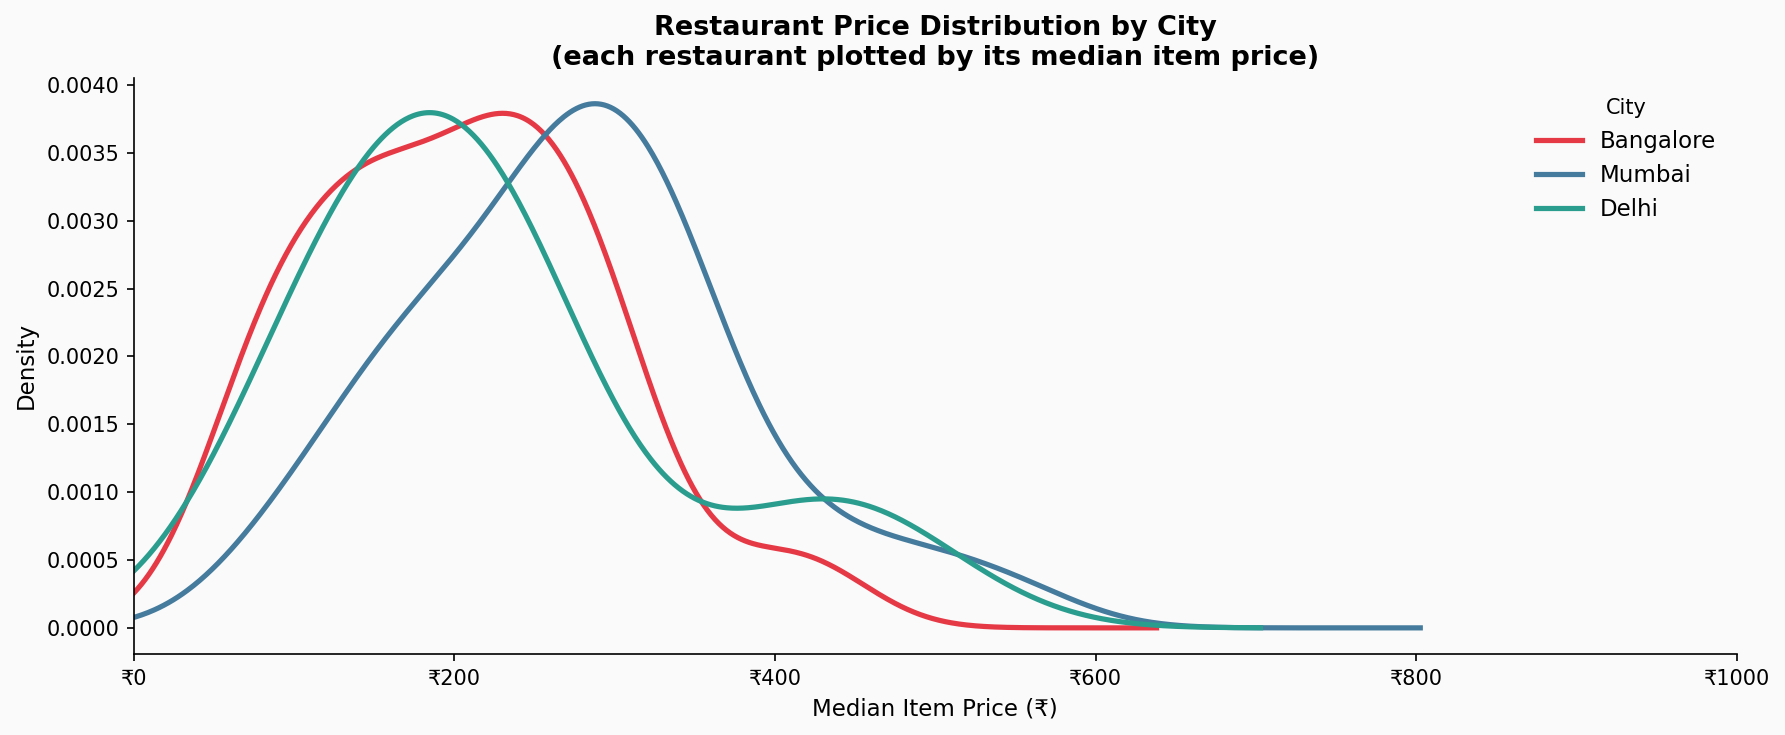

    ✓  Saved successfully to: zomato_analysis_outputs\EDA3_price_distributions.png


In [73]:
# ── EDA Chart 3: Price Distributions ──────────────────────────────────────────
# Question: Is Mumbai genuinely more premium — or just more spread out?
# The shape of the distribution matters, not just the mean.
print("  [EDA-3] Price distributions...")
 
fig, ax = plt.subplots(figsize=(12, 5))
for city in CITIES:
    city_rest[city]['median_price'].dropna().plot.kde(
        ax=ax, color=CITY_COLORS[city], linewidth=2.5, label=city
    )
ax.set_title("Restaurant Price Distribution by City\n"
             "(each restaurant plotted by its median item price)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Median Item Price (₹)")
ax.set_ylabel("Density")
ax.legend(title="City", fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"₹{int(x)}"))
ax.set_xlim(0, 1000)
plt.tight_layout()
save(fig, "EDA3_price_distributions.png")

## Key Observations

### Mumbai
- The price distribution is shifted toward higher values compared to other cities.
- Peak density occurs approximately between ₹280 and ₹320.
- The distribution shows the widest spread, extending to higher price points.

**Observation:**  
Mumbai represents the most premium market, with higher average pricing and greater variability, indicating the presence of both mid-range and high-end restaurants.

---

### Bangalore
- The distribution peaks around ₹200 to ₹250.
- Prices are moderately spread, primarily within the ₹100 to ₹400 range.
- Limited presence of extreme high-price outliers.

**Observation:**  
Bangalore reflects a balanced pricing structure, with a strong concentration of mid-range restaurants and moderate diversity in pricing.

---

### Delhi
- The distribution peaks at a lower range, approximately ₹150 to ₹200.
- The majority of restaurants fall within the lower to mid-price segments.
- A smaller tail extends toward higher prices.

**Observation:**  
Delhi appears to be relatively more affordable, with a concentration of budget and mid-range dining options.

---

## 2. Cross-City Comparison

### Pricing Levels
- Mumbai has the highest pricing levels overall.
- Bangalore occupies a middle position.
- Delhi shows the lowest average pricing.

---

### Price Variability
- Mumbai exhibits the highest variability in pricing.
- Bangalore shows moderate variability.
- Delhi has the most concentrated (least variable) price distribution.

---

### Common Pricing Range
A significant overlap is observed across all cities in the ₹150 to ₹350 range, indicating a shared competitive pricing band for restaurants.

---

## 3. Key Takeaways

- Mumbai is the most premium and diverse pricing market.
- Bangalore provides a balanced mix of affordability and mid-range options.
- Delhi is comparatively more budget-friendly.
- The ₹150 to ₹350 range represents the core pricing segment across all three cities.

---

  [EDA-4] Top cuisines by city...


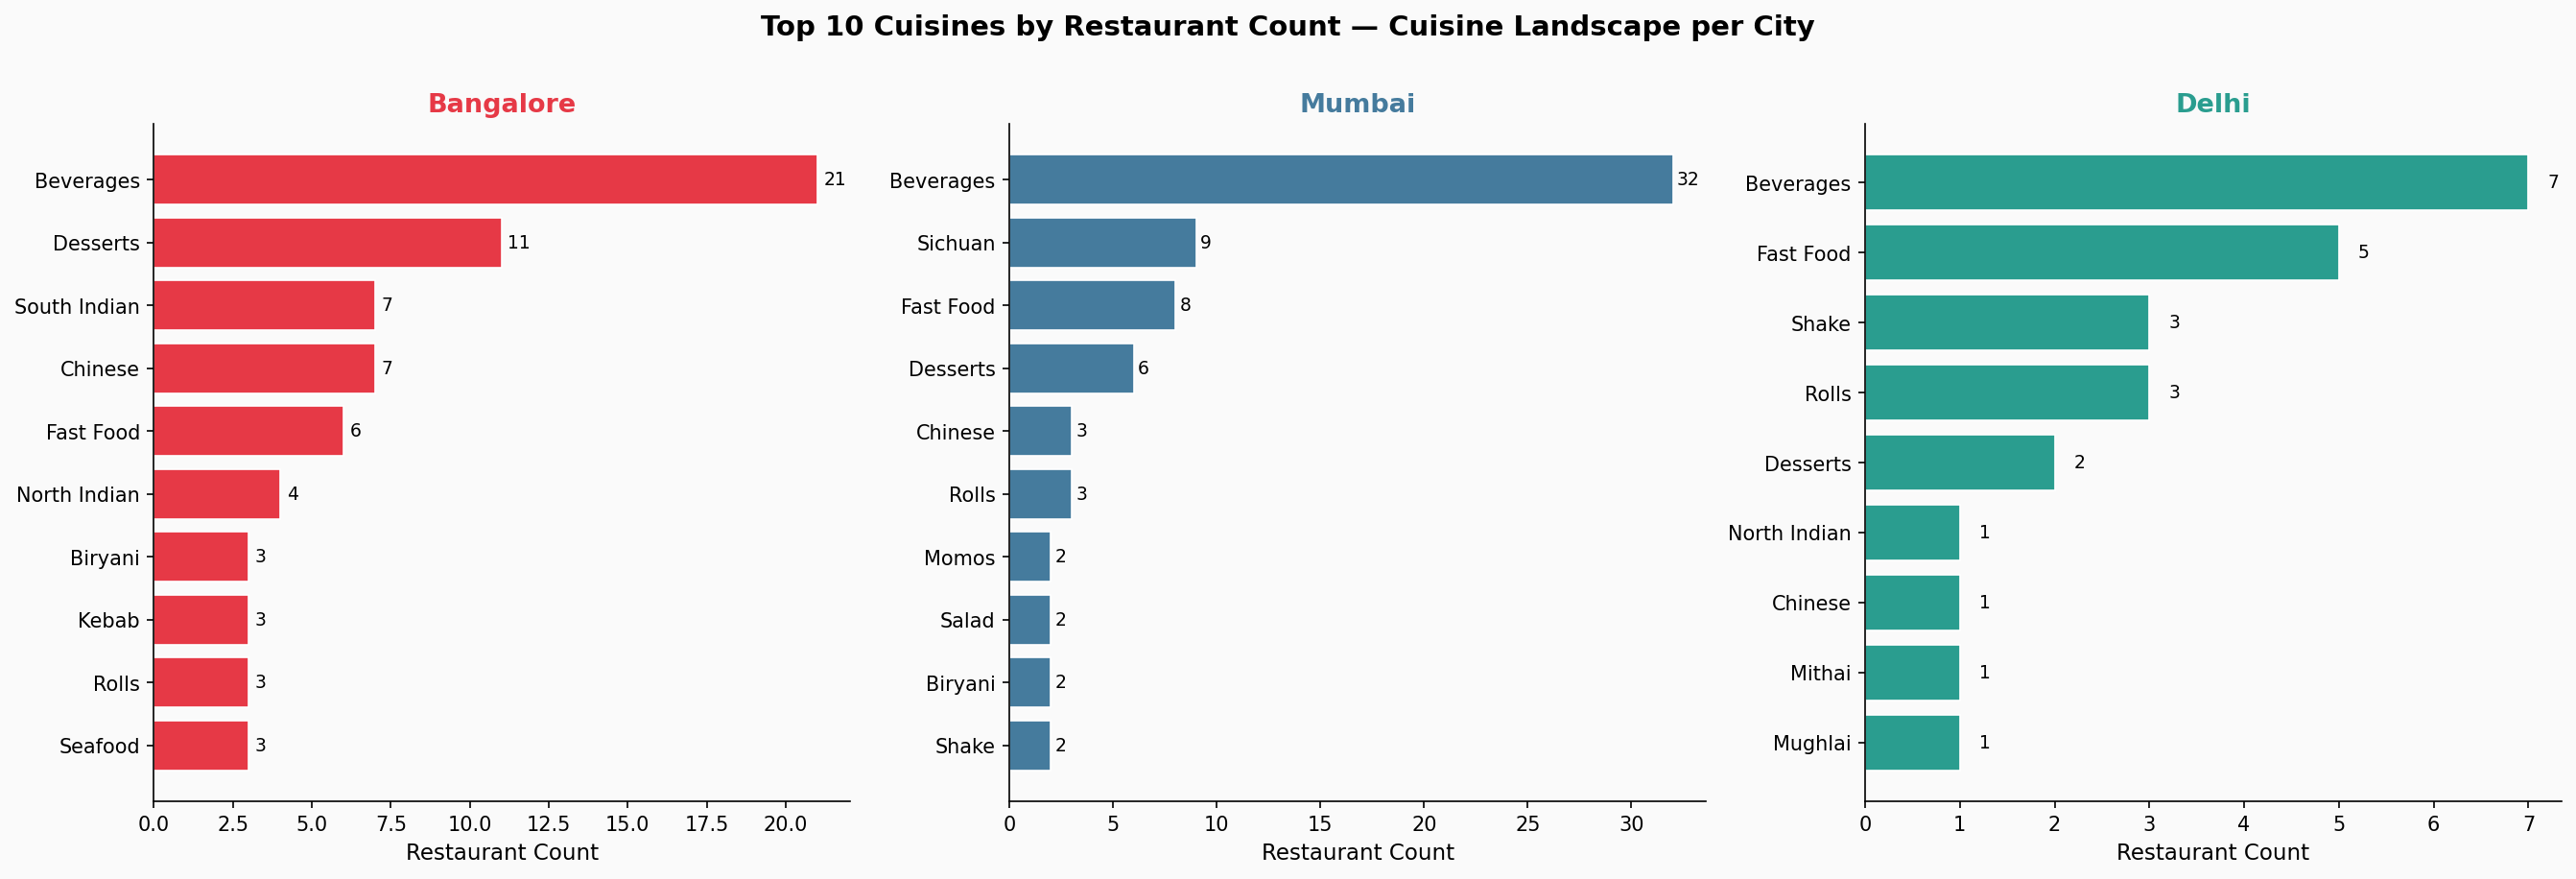

    ✓  Saved successfully to: zomato_analysis_outputs\EDA4_top_cuisines.png

  ✅  EDA complete.


In [76]:
# ── EDA Chart 4: Top Cuisines per City ────────────────────────────────────────
# Question: Do cities have different cuisine ecosystems?
# This tells us whether cuisine is a city-specific variable worth analysing.
print("  [EDA-4] Top cuisines by city...")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 10 Cuisines by Restaurant Count — Cuisine Landscape per City",
             fontsize=14, fontweight="bold", y=1.01)
 
for ax, city in zip(axes, CITIES):
    top = (rest[rest['City'] == city]['Cuisine']
           .value_counts().head(10).sort_values())
    bars = ax.barh(top.index, top.values,
                   color=CITY_COLORS[city], edgecolor="white", linewidth=0.8)
    ax.set_title(city, color=CITY_COLORS[city], fontsize=13, fontweight="bold")
    ax.set_xlabel("Restaurant Count")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
                f"{int(w)}", va="center", fontsize=9)
 
plt.tight_layout()
save(fig, "EDA4_top_cuisines.png")
 
print(f"\n  ✅  EDA complete.")

## Key Observations

### Bangalore
- Beverages represent the largest category (21), followed by Desserts (11).
- Mid-range categories include South Indian and Chinese (7 each), and Fast Food (6).
- Other cuisines such as North Indian, Biryani, Kebab, Rolls, and Seafood have relatively lower representation.

**Observation:**  
Bangalore demonstrates a well-balanced food ecosystem with a strong inclination toward café culture and dessert-oriented outlets, alongside a mix of regional and international cuisines.

---

### Mumbai
- Beverages dominate significantly (32), the highest across all cities.
- Other prominent categories include Sichuan (9), Fast Food (8), and Desserts (6).
- Remaining cuisines such as Chinese, Rolls, Momos, Salad, Biryani, and Shakes have relatively smaller shares.

**Observation:**  
Mumbai exhibits the largest market scale, with a strong emphasis on beverages and a noticeable presence of international cuisines, indicating a diverse and competitive food environment.

---

### Delhi
- Overall restaurant counts are lower compared to Bangalore and Mumbai.
- Beverages lead (7), followed by Fast Food (5).
- Categories such as Shakes and Rolls (3 each) show moderate presence.
- Traditional cuisines like North Indian, Chinese, Mithai, and Mughlai have minimal representation.

**Observation:**  
Delhi’s cuisine distribution appears more concentrated in quick-service formats, with comparatively limited diversity in high-frequency categories.

---

## 2. Cross-City Comparison

### Dominance of Beverages
Beverages consistently rank as the top category across all three cities:
- Bangalore: 21  
- Mumbai: 32  
- Delhi: 7  

This trend reflects the growing prominence of café culture and beverage-focused establishments in urban markets.

---

### Market Scale Differences
- Mumbai has the highest counts across most categories, indicating a larger and more competitive restaurant landscape.
- Bangalore maintains moderate scale with balanced distribution.
- Delhi shows relatively lower counts, suggesting either a smaller sample or a more concentrated market.

---

### Diversity of Cuisine
- Bangalore exhibits the most balanced spread across cuisines.
- Mumbai shows diversity with a tilt toward global cuisine options.
- Delhi demonstrates a narrower distribution, with emphasis on fast food and snacks.

---

### Distinct City Characteristics
- Mumbai stands out for its strong presence of Sichuan cuisine.
- Bangalore highlights regional preferences with South Indian cuisine.
- Delhi includes traditional offerings such as Mithai and Mughlai, though in smaller numbers.

---

## 3. Key Takeaways

- Beverage-oriented establishments dominate across all cities, indicating a major consumption trend.
- Mumbai leads in overall restaurant density and category scale.
- Bangalore reflects a balanced and diverse culinary ecosystem.
- Delhi shows a stronger inclination toward quick-service and snack-based dining formats.

---

#  CHAPTER 4 — BUSINESS ANALYSIS

In [80]:
#  Central question: "What makes a restaurant successful — and does the answer
#                     differ between Bangalore, Mumbai, and Delhi?"
#
#  We test six specific hypotheses. Each analysis tests one hypothesis.
#  We do not just describe patterns — we argue for conclusions.
#
# =============================================================================
 
print("\n" + "="*70)
print("  CHAPTER 4 — BUSINESS ANALYSIS")
print("  Six hypotheses tested against the data.")
print("="*70)


  CHAPTER 4 — BUSINESS ANALYSIS
  Six hypotheses tested against the data.



  [A] Does price positioning differ between successful & unsuccessful?


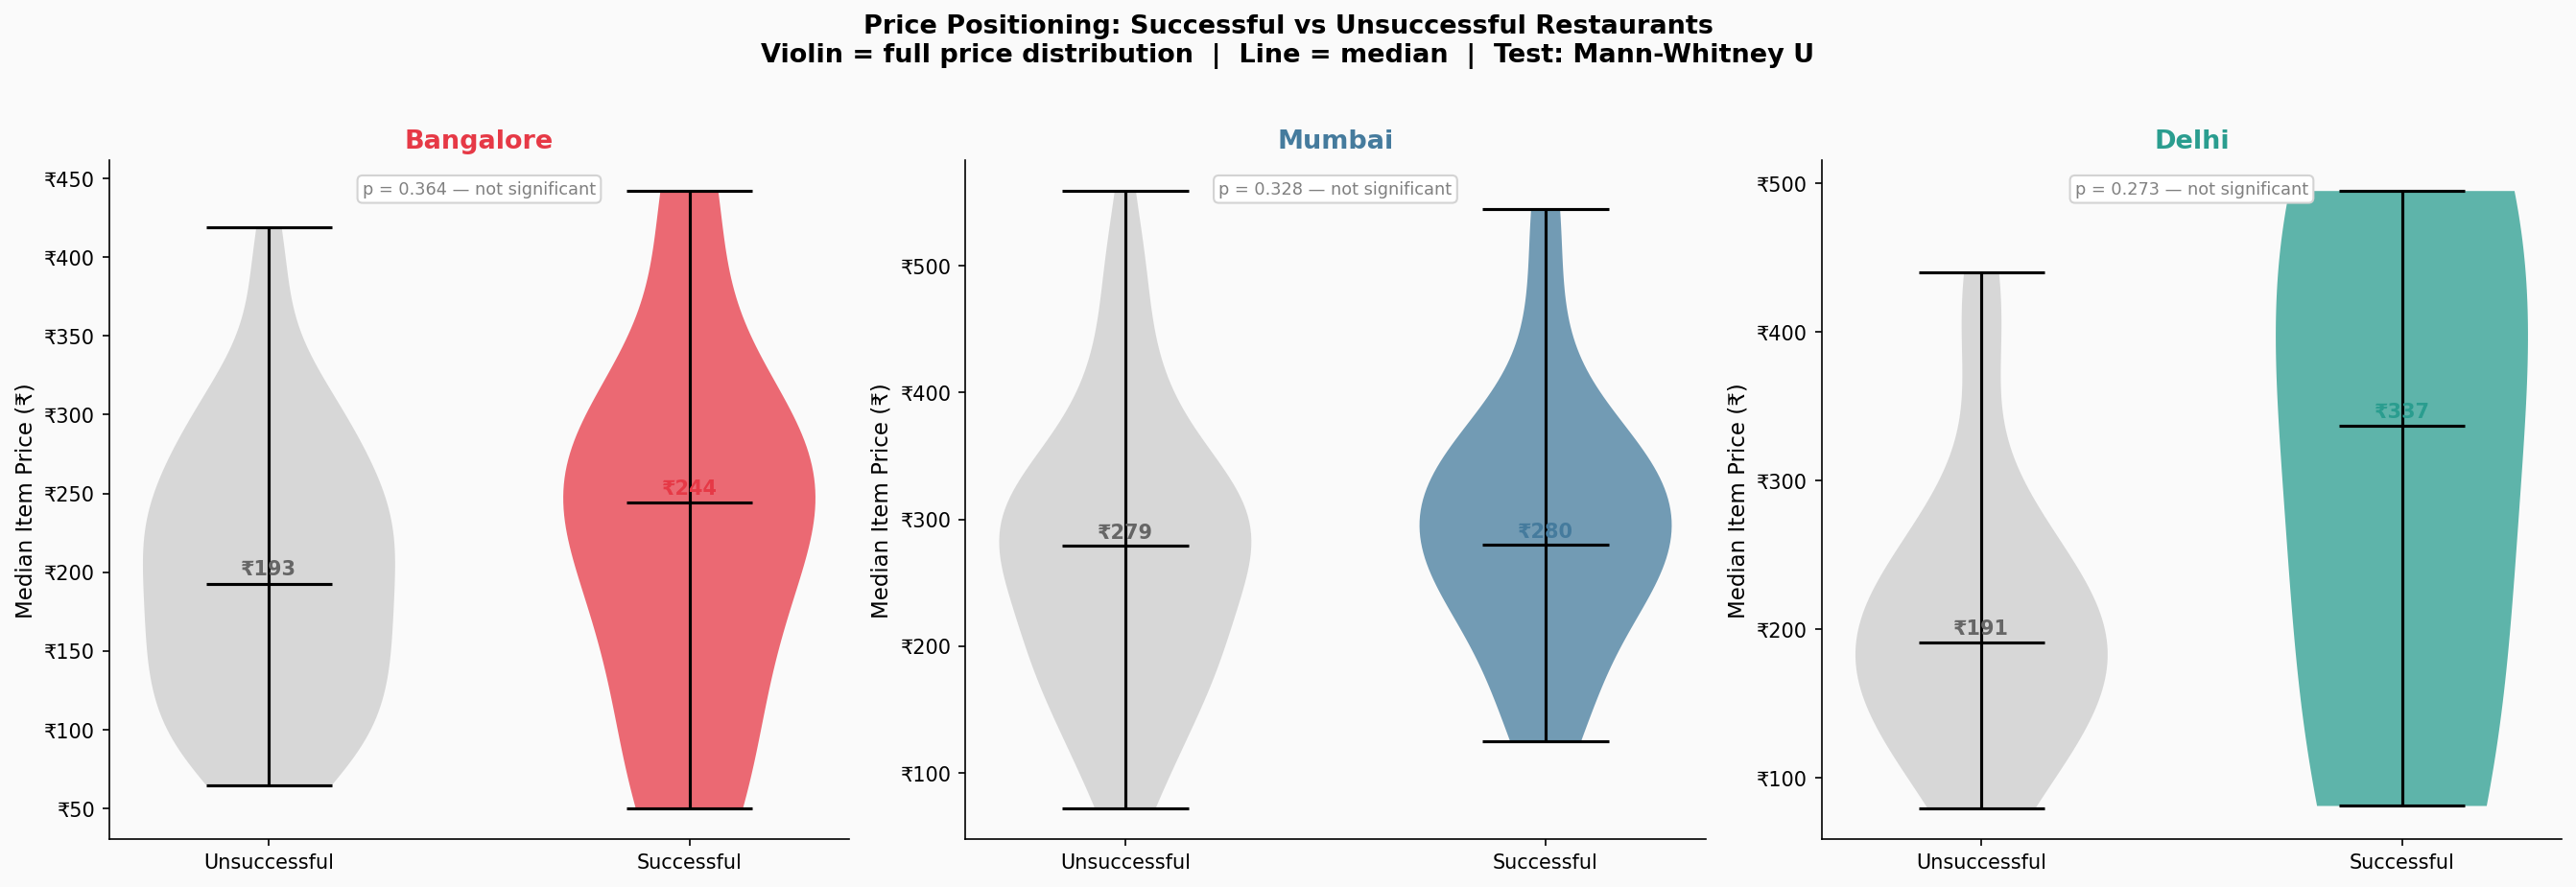

    ✓  Saved successfully to: zomato_analysis_outputs\BIZA_price_vs_success.png

    Price premium of successful over unsuccessful restaurants:
    Bangalore   : ₹244 (success) vs ₹193 (others) → Δ = ₹+51
    Mumbai      : ₹280 (success) vs ₹279 (others) → Δ = ₹+1
    Delhi       : ₹337 (success) vs ₹191 (others) → Δ = ₹+146


In [83]:
#  ANALYSIS A — Price & Success
#  Hypothesis: Successful restaurants charge more than unsuccessful ones.
#  Secondary question: Is this effect city-specific, or universal?
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [A] Does price positioning differ between successful & unsuccessful?")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Price Positioning: Successful vs Unsuccessful Restaurants\n"
             "Violin = full price distribution  |  Line = median  |  Test: Mann-Whitney U",
             fontsize=13, fontweight="bold", y=1.02)
 
for ax, city in zip(axes, CITIES):
    cdf   = rest[rest['City'] == city]
    s_yes = cdf[cdf['is_successful'] == 1]['median_price'].dropna()
    s_no  = cdf[cdf['is_successful'] == 0]['median_price'].dropna()
 
    parts = ax.violinplot([s_no, s_yes], positions=[0, 1],
                          showmedians=True, widths=0.6)
    for pc, col in zip(parts['bodies'], ["#CCCCCC", CITY_COLORS[city]]):
        pc.set_facecolor(col)
        pc.set_alpha(0.75)
    for key in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
        parts[key].set_color("black")
 
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Unsuccessful", "Successful"], fontsize=10)
    ax.set_title(city, color=CITY_COLORS[city], fontsize=13, fontweight="bold")
    ax.set_ylabel("Median Item Price (₹)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"₹{int(x)}"))
 
    for pos, grp, c in [(0, s_no, "#666666"), (1, s_yes, CITY_COLORS[city])]:
        med = grp.median()
        ax.text(pos, med + 3, f"₹{med:.0f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=c)
 
    # Mann-Whitney U: non-parametric test chosen because price distributions
    # are right-skewed (confirmed in EDA-3) — ANOVA assumes normality.
    u_stat, p = stats.mannwhitneyu(s_yes, s_no, alternative="two-sided")
    sig = "★ p < 0.05 — significant" if p < 0.05 else f"p = {p:.3f} — not significant"
    ax.text(0.5, 0.97, sig, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray"))
 
plt.tight_layout()
save(fig, "BIZA_price_vs_success.png")
 
print(f"\n    Price premium of successful over unsuccessful restaurants:")
for city in CITIES:
    cdf = rest[rest['City'] == city]
    s   = cdf[cdf['is_successful']==1]['median_price'].median()
    f   = cdf[cdf['is_successful']==0]['median_price'].median()
    print(f"    {city:12s}: ₹{s:.0f} (success) vs ₹{f:.0f} (others) → Δ = ₹{s-f:+.0f}")

### Price Positioning and Restaurant Success

This analysis evaluates whether successful restaurants adopt different pricing strategies compared to unsuccessful ones across Bangalore, Mumbai, and Delhi. Median item prices are compared using violin plots, and statistical significance is assessed using the Mann-Whitney U test.

---

#### 1. Key Observations

#### Bangalore
- Successful: ₹244  
- Unsuccessful: ₹193  
- Difference: +₹51  

**Observation:**  
Successful restaurants tend to charge higher prices, indicating a moderate premium positioning.

---

#### Mumbai
- Successful: ₹280  
- Unsuccessful: ₹279  
- Difference: ~₹0  

**Observation:**  
There is virtually no difference in pricing between successful and unsuccessful restaurants.

---

#### Delhi
- Successful: ₹337  
- Unsuccessful: ₹191  
- Difference: +₹146  

**Observation:**  
A substantial price difference is observed, suggesting that successful restaurants are positioned in significantly higher price segments.

---

#### 2. Statistical Analysis

A Mann-Whitney U test was conducted to compare price distributions:

- Bangalore: p = 0.364  
- Mumbai: p = 0.328  
- Delhi: p = 0.273  

**Interpretation:**  
All p-values exceed the significance threshold (α = 0.05), indicating that the observed differences are not statistically significant. Therefore, pricing alone cannot be considered a reliable determinant of restaurant success.

---

#### 3. Cross-City Insights

- Bangalore and Delhi show a tendency for successful restaurants to charge higher prices.
- Mumbai shows no meaningful pricing difference between success groups.
- Price distributions for successful restaurants are generally wider, indicating diverse pricing strategies.

---

#### 4. Key Takeaways

- Successful restaurants often exhibit higher pricing, particularly in Delhi.
- However, these differences are not statistically significant.
- Pricing alone does not explain restaurant success.

---


  [B] Which cuisines succeed — and does the winner change by city?


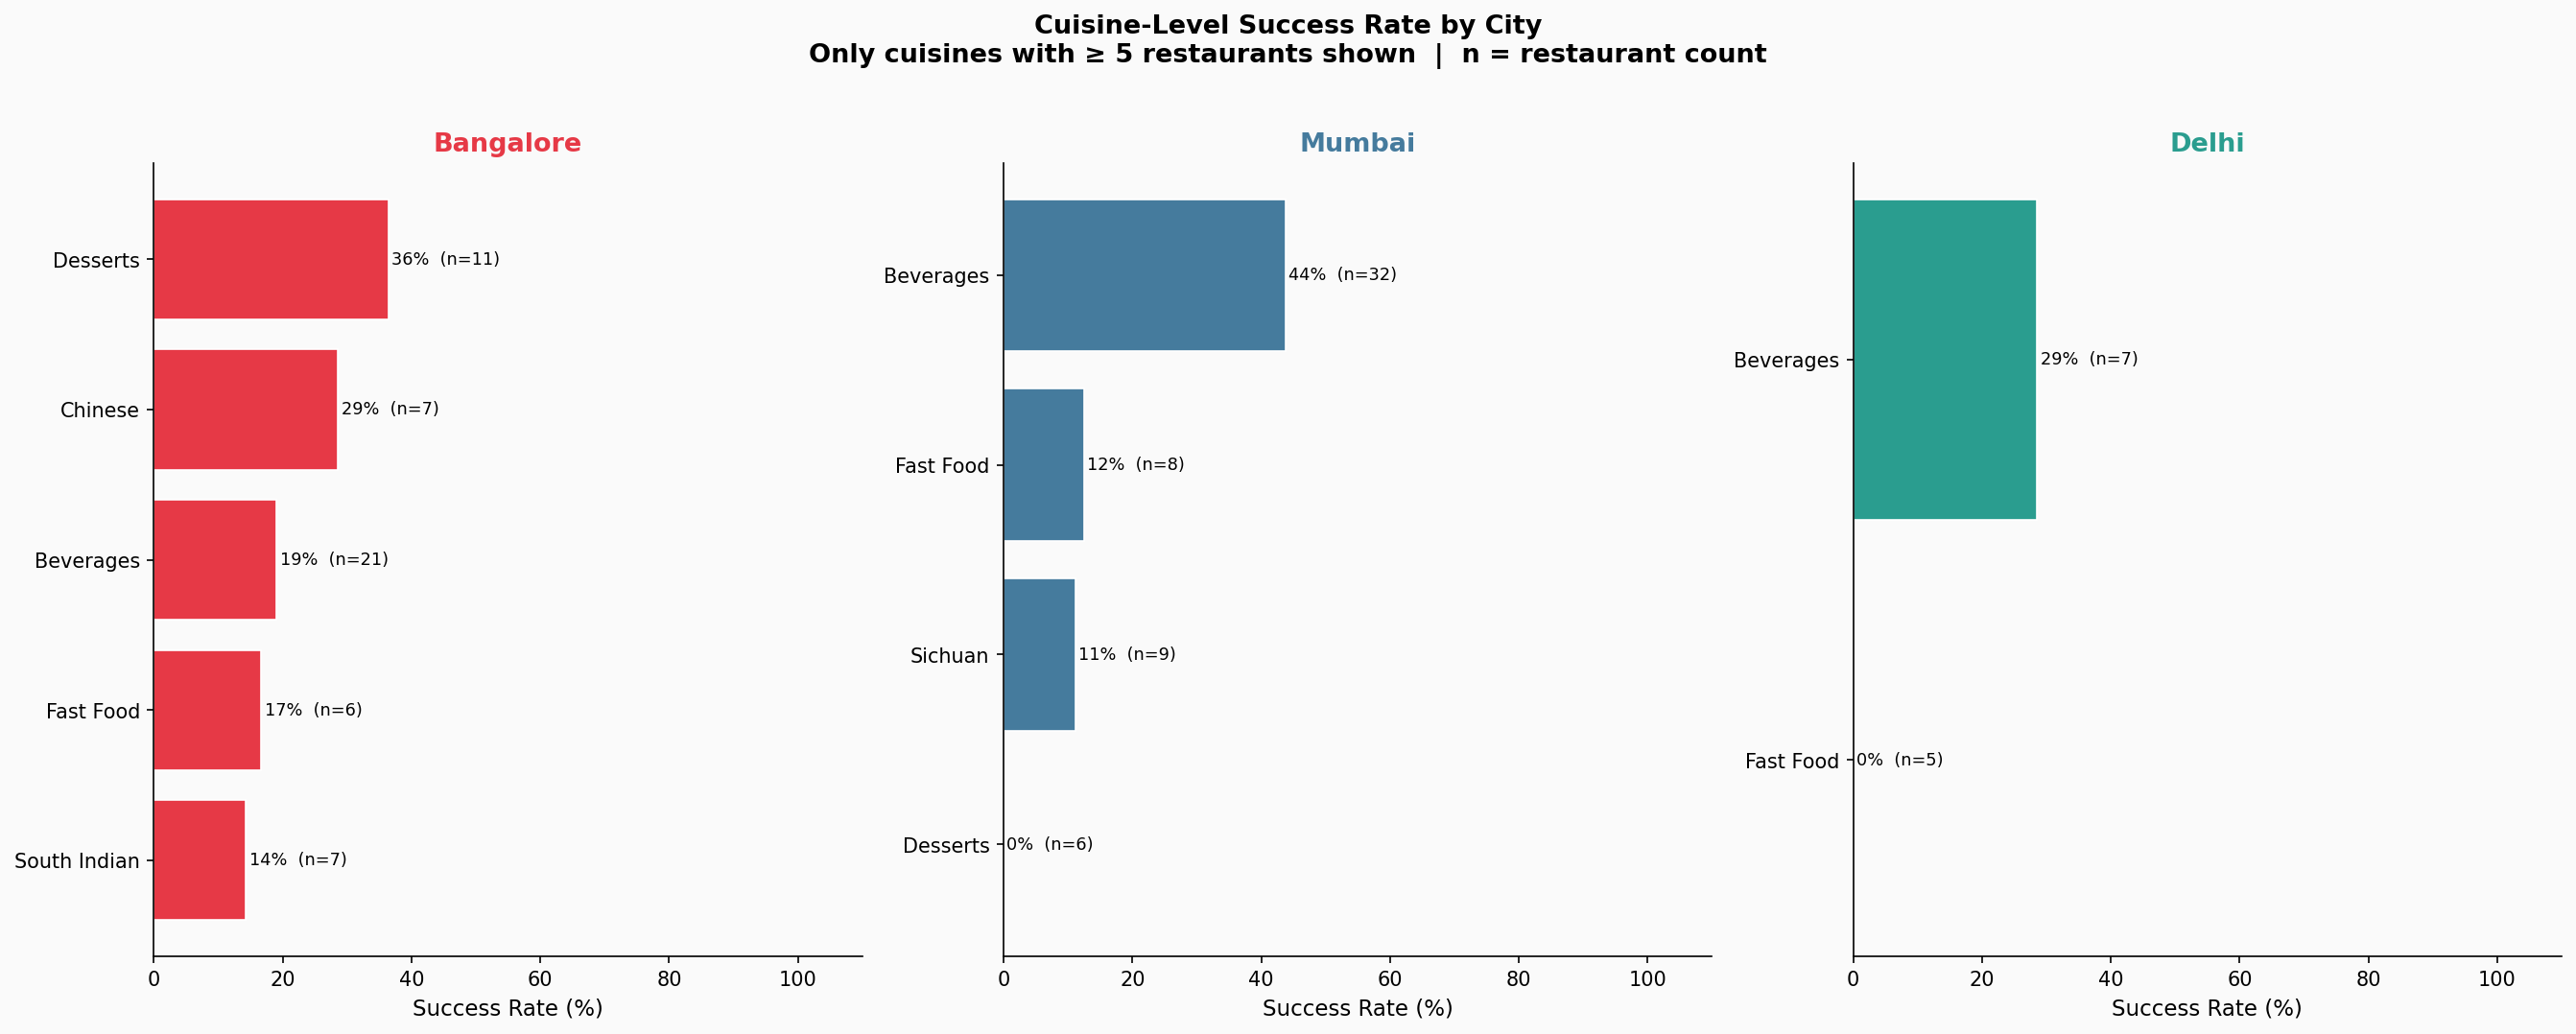

    ✓  Saved successfully to: zomato_analysis_outputs\BIZB_cuisine_success.png


In [84]:
#  ANALYSIS B — Cuisine & Success
#  Hypothesis: Success rates are not equal across cuisines.
#              The winning cuisine category differs by city.
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [B] Which cuisines succeed — and does the winner change by city?")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Cuisine-Level Success Rate by City\n"
             "Only cuisines with ≥ 5 restaurants shown  |  n = restaurant count",
             fontsize=13, fontweight="bold", y=1.02)
 
for ax, city in zip(axes, CITIES):
    cdf = rest[rest['City'] == city]
    cs  = (cdf.groupby('Cuisine')
              .agg(success_rate=('is_successful', 'mean'),
                   count=('is_successful', 'count'))
              .query("count >= 5")
              .sort_values('success_rate', ascending=True)
              .tail(12))
    bars = ax.barh(cs.index, cs['success_rate'] * 100,
                   color=CITY_COLORS[city], edgecolor="white", linewidth=0.8)
    ax.set_title(city, color=CITY_COLORS[city], fontsize=13, fontweight="bold")
    ax.set_xlabel("Success Rate (%)")
    ax.set_xlim(0, 110)
    for bar, (_, row) in zip(bars, cs.iterrows()):
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f"{w:.0f}%  (n={int(row['count'])})",
                va="center", fontsize=8.5)
 
plt.tight_layout()
save(fig, "BIZB_cuisine_success.png")

### Cuisine-Level Success Rate by City

This analysis evaluates the success rate of different cuisines across Bangalore, Mumbai, and Delhi. Only cuisines with at least five restaurants are included to ensure meaningful interpretation. Success rate is defined as the percentage of restaurants classified as successful within each cuisine.

---

#### 1. Bangalore

- Desserts: 36% (n=11)  
- Chinese: 29% (n=7)  
- Beverages: 19% (n=21)  
- Fast Food: 17% (n=6)  
- South Indian: 14% (n=7)  

**Observation:**  
Dessert and Chinese cuisines show the highest success rates, while traditional South Indian cuisine shows relatively lower success.

---

#### 2. Mumbai

- Beverages: 44% (n=32)  
- Fast Food: 12% (n=8)  
- Sichuan: 11% (n=9)  
- Desserts: 0% (n=6)  

**Observation:**  
Beverage-based establishments dominate in success rate, while dessert-focused businesses underperform.

---

#### 3. Delhi

- Beverages: 29% (n=7)  
- Fast Food: 0% (n=5)  

**Observation:**  
Success is concentrated in beverages, while fast food shows no success despite representation.

---

#### 4. Cross-City Insights

#### Beverages
Beverage-focused businesses demonstrate consistently strong performance across all cities.

#### Desserts
Desserts perform well in Bangalore but not in Mumbai, highlighting city-specific consumer behavior.

#### Fast Food
Fast food shows limited success across cities, suggesting high competition or lower differentiation.

---

#### 5. Key Takeaways

- Beverage-led models are the most resilient and scalable across cities.
- Cuisine success is highly city-dependent.
- Popular cuisines do not always translate into higher success rates.
- Strategic positioning by cuisine and city is essential for higher success probability.

---

  [C] Does price correlate with delivery rating — and how strongly?


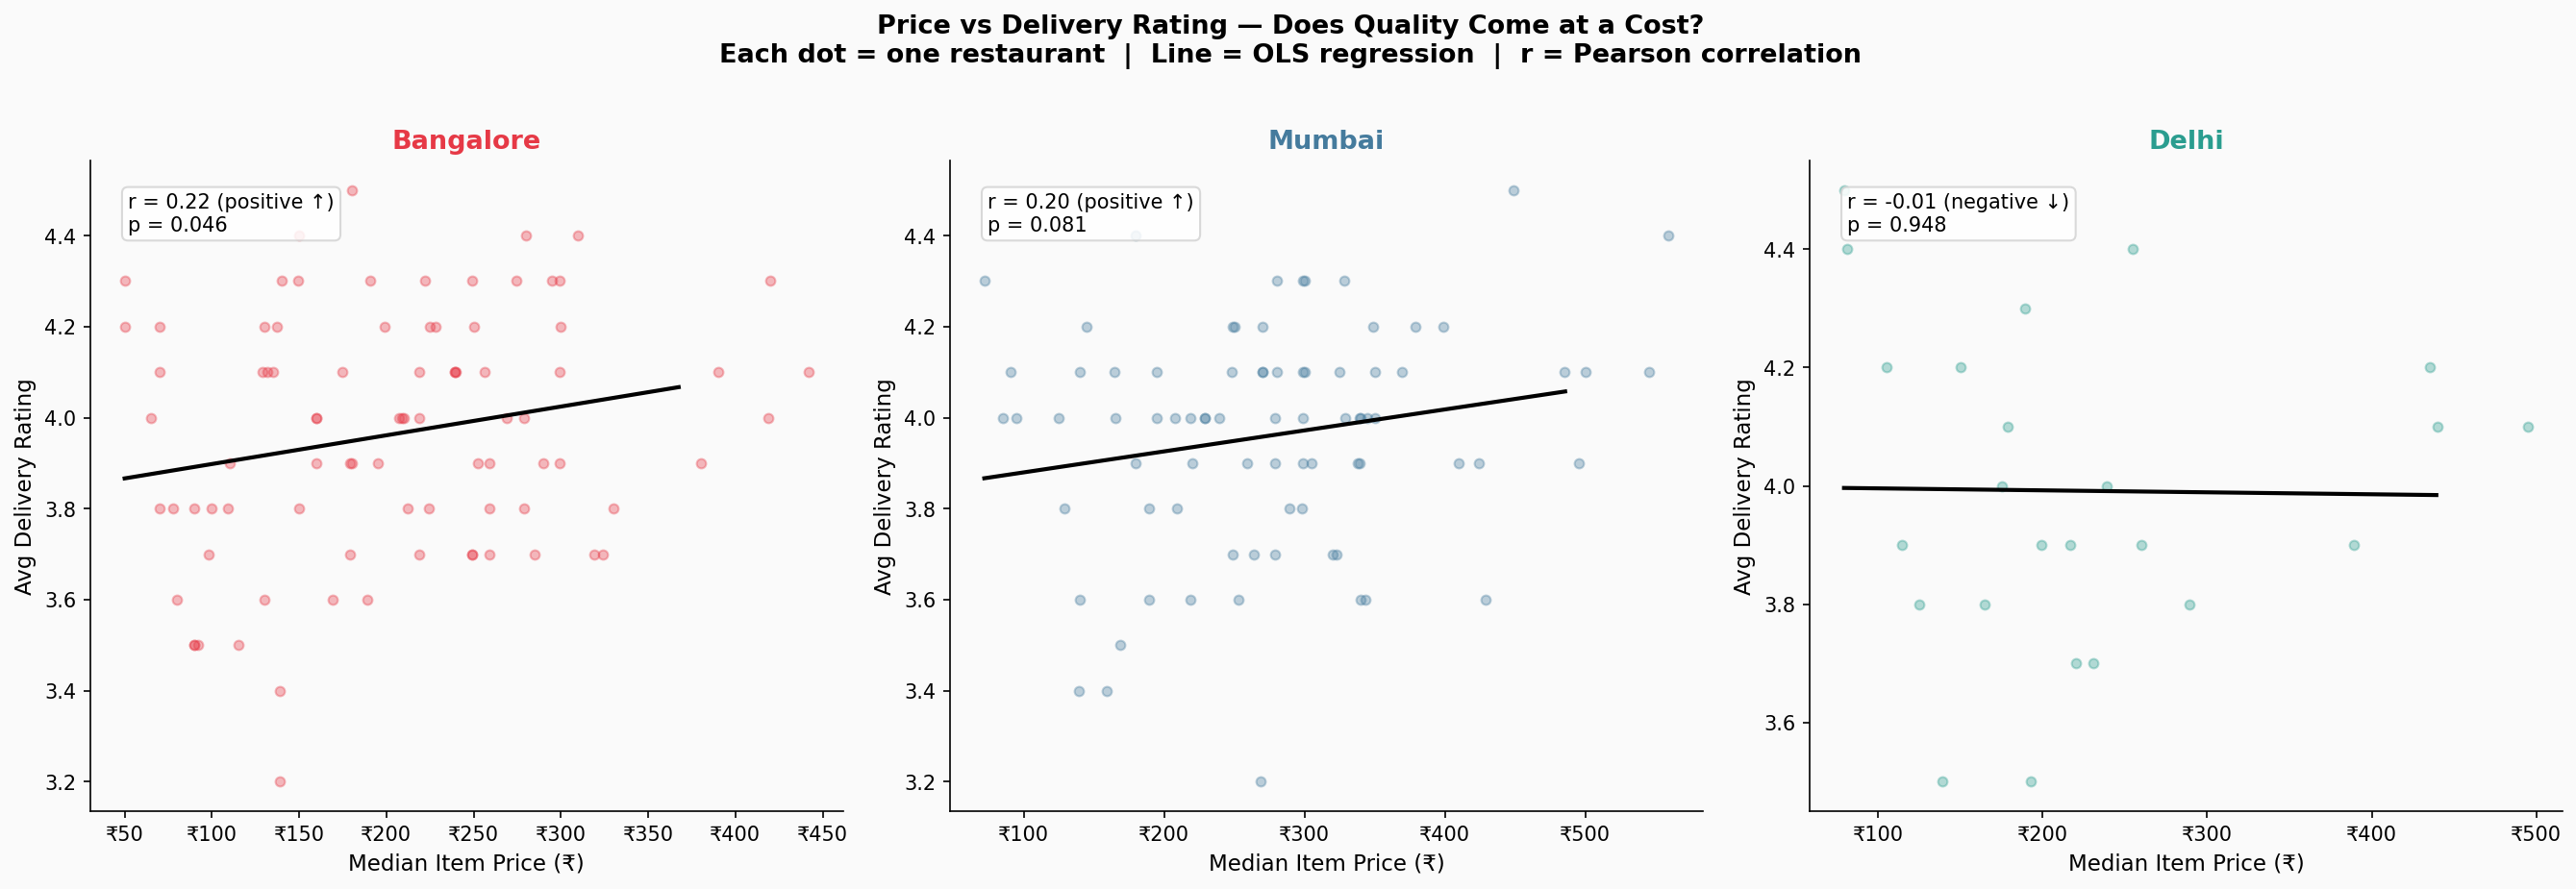

    ✓  Saved successfully to: zomato_analysis_outputs\BIZC_price_vs_rating.png


In [85]:
#  ANALYSIS C — Price vs Rating Correlation
#  Hypothesis: Higher-priced restaurants earn higher delivery ratings.
#  We test this with linear regression per city and compare the slopes and r values.
# ─────────────────────────────────────────────────────────────────────────────
print("  [C] Does price correlate with delivery rating — and how strongly?")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Price vs Delivery Rating — Does Quality Come at a Cost?\n"
             "Each dot = one restaurant  |  Line = OLS regression  |  r = Pearson correlation",
             fontsize=13, fontweight="bold", y=1.02)
 
for ax, city in zip(axes, CITIES):
    cdf = rest[rest['City'] == city].dropna(
        subset=['median_price', 'delivery_rating']
    )
    ax.scatter(cdf['median_price'], cdf['delivery_rating'],
               alpha=0.35, s=22, color=CITY_COLORS[city])
 
    slope, intercept, r, p, _ = stats.linregress(
        cdf['median_price'], cdf['delivery_rating']
    )
    x_line = np.linspace(
        cdf['median_price'].min(),
        cdf['median_price'].quantile(0.95), 200
    )
    ax.plot(x_line, slope * x_line + intercept,
            color="black", linewidth=2, zorder=5)
 
    direction = "positive ↑" if slope > 0 else "negative ↓"
    ax.set_title(city, color=CITY_COLORS[city], fontsize=13, fontweight="bold")
    ax.set_xlabel("Median Item Price (₹)")
    ax.set_ylabel("Avg Delivery Rating")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"₹{int(x)}"))
    ax.text(0.05, 0.95,
            f"r = {r:.2f} ({direction})\np = {p:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white",
                      edgecolor="lightgray", alpha=0.85))
 
plt.tight_layout()
save(fig, "BIZC_price_vs_rating.png")

### Price vs Delivery Rating: Does Quality Come at a Cost?

This analysis examines the relationship between restaurant pricing and delivery ratings across Bangalore, Mumbai, and Delhi. Each point represents a restaurant, with regression lines indicating trend direction and Pearson correlation coefficients quantifying strength.

---

#### 1. Bangalore

- Correlation coefficient: r = 0.22  
- p-value: 0.046  

**Interpretation:**  
A weak but statistically significant positive correlation exists between price and delivery rating, indicating that higher-priced restaurants tend to have slightly better ratings.

---

#### 2. Mumbai

- Correlation coefficient: r = 0.20  
- p-value: 0.081  

**Interpretation:**  
Although a positive trend is observed, the relationship is not statistically significant. There is insufficient evidence to conclude that higher pricing leads to better delivery ratings.

---

#### 3. Delhi

- Correlation coefficient: r = -0.01  
- p-value: 0.948  

**Interpretation:**  
No meaningful relationship exists between pricing and delivery ratings.

---

#### 4. Cross-City Comparison

- Bangalore exhibits a weak but significant price–quality relationship.
- Mumbai and Delhi show no significant relationship.
- Overall, price is not a strong predictor of customer satisfaction.

---

#### 5. Key Takeaways

- Higher pricing does not consistently correspond to higher delivery ratings.
- Customer satisfaction appears to be influenced by factors beyond pricing.
- Pricing strategy alone is insufficient to explain quality perception.

---

  [D] Do successful restaurants have a different menu strategy?


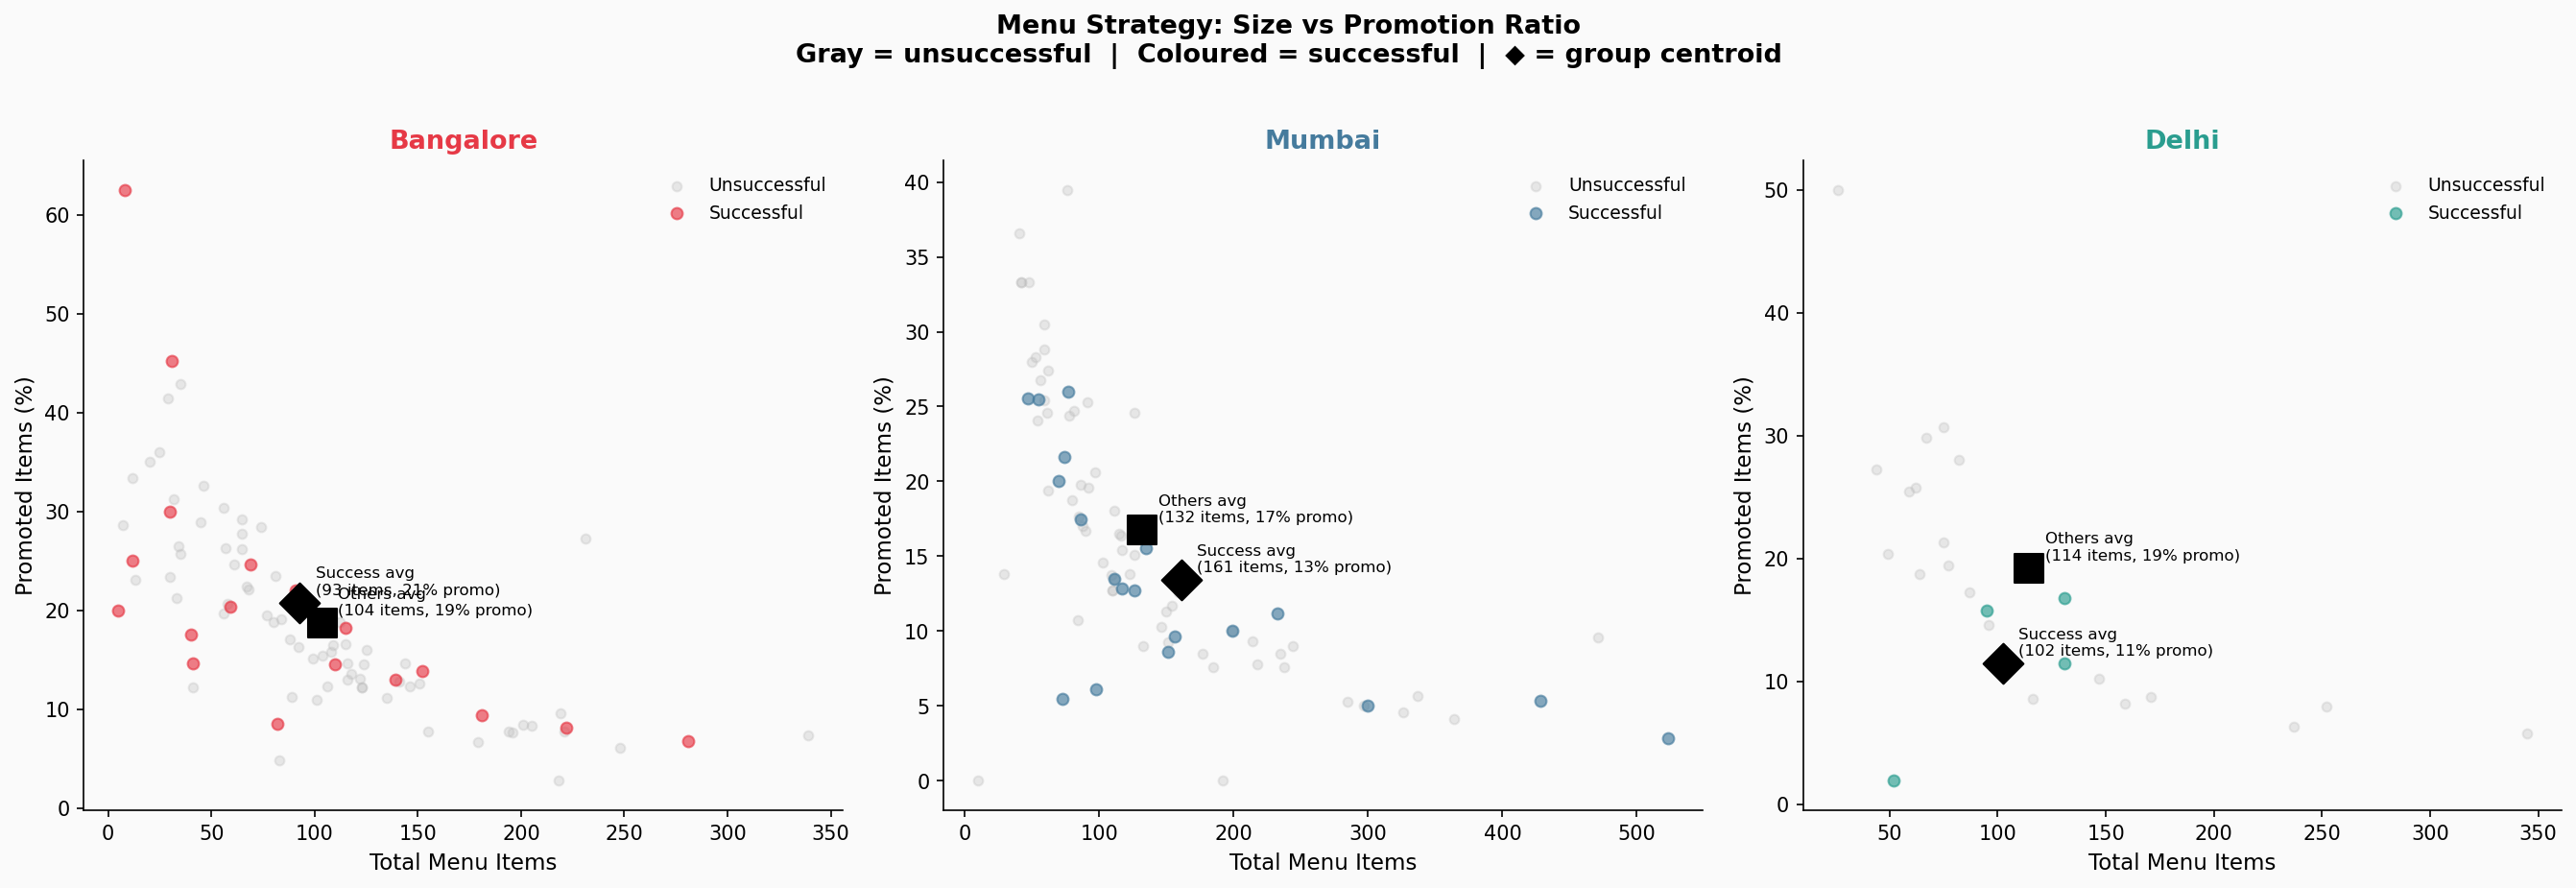

    ✓  Saved successfully to: zomato_analysis_outputs\BIZD_menu_strategy.png


In [86]:
#  ANALYSIS D — Menu Strategy
#  Hypothesis: Successful restaurants have a deliberate menu footprint —
#  their menu size and promotion ratio differ from unsuccessful restaurants.
# ─────────────────────────────────────────────────────────────────────────────
print("  [D] Do successful restaurants have a different menu strategy?")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Menu Strategy: Size vs Promotion Ratio\n"
             "Gray = unsuccessful  |  Coloured = successful  |  ◆ = group centroid",
             fontsize=13, fontweight="bold", y=1.02)
 
for ax, city in zip(axes, CITIES):
    cdf = rest[rest['City'] == city]
    yes = cdf[cdf['is_successful'] == 1]
    no  = cdf[cdf['is_successful'] == 0]
 
    ax.scatter(no['total_items'],  no['promo_ratio']  * 100,
               alpha=0.3, s=22, color="#BBBBBB", label="Unsuccessful", zorder=2)
    ax.scatter(yes['total_items'], yes['promo_ratio'] * 100,
               alpha=0.65, s=32, color=CITY_COLORS[city], label="Successful", zorder=3)
 
    for grp, marker, lbl in [(yes, "D", "Success avg"), (no, "s", "Others avg")]:
        mx, my = grp['total_items'].mean(), grp['promo_ratio'].mean() * 100
        ax.scatter(mx, my, marker=marker, s=200, color="black", zorder=6)
        ax.annotate(f"{lbl}\n({mx:.0f} items, {my:.0f}% promo)",
                    (mx, my), textcoords="offset points",
                    xytext=(8, 4), fontsize=8)
 
    ax.set_title(city, color=CITY_COLORS[city], fontsize=13, fontweight="bold")
    ax.set_xlabel("Total Menu Items")
    ax.set_ylabel("Promoted Items (%)")
    ax.legend(fontsize=9)
 
plt.tight_layout()
save(fig, "BIZD_menu_strategy.png")

### Menu Strategy: Size vs Promotion Ratio

This analysis examines how menu size and promotional intensity relate to restaurant success across Bangalore, Mumbai, and Delhi. Each point represents a restaurant, with successful restaurants highlighted and group centroids indicating average positioning.

---

#### 1. Bangalore

- Successful restaurants average approximately 90 menu items and 21% promotional items.
- Unsuccessful restaurants average approximately 104 menu items and 19% promotional items.

**Interpretation:**  
Successful restaurants tend to operate with smaller menus and slightly higher promotional activity, indicating a focus on curated offerings supported by active promotions.

---

#### 2. Mumbai

- Successful restaurants average approximately 161 menu items and 13% promotional items.
- Unsuccessful restaurants average approximately 132 menu items and 17% promotional items.

**Interpretation:**  
Successful restaurants in Mumbai tend to offer larger menus with lower reliance on promotions, suggesting that assortment breadth is a stronger driver of success than discounting.

---

#### 3. Delhi

- Successful restaurants average approximately 102 menu items and 11% promotional items.
- Unsuccessful restaurants average approximately 114 menu items and 19% promotional items.

**Interpretation:**  
Successful restaurants operate with slightly smaller menus and significantly lower promotional intensity, indicating a focus on curation and reduced discounting.

---

#### 4. Cross-City Insights

- Optimal menu size varies by city: Mumbai favors larger menus, while Bangalore and Delhi favor more curated menus.
- Promotion strategies differ by market: lower promotional intensity aligns with success in Mumbai and Delhi, while Bangalore shows the opposite trend.
- There is no universal menu strategy; effectiveness depends on market context.

---

#### 5. Key Takeaways

- Menu strategy should be tailored to city-specific market dynamics.
- Larger menus support success in some markets, while curated menus perform better in others.
- Promotions are not universally beneficial and may reduce perceived value in certain markets.

---

  [E] Does the Bestseller label actually drive demand and pricing?


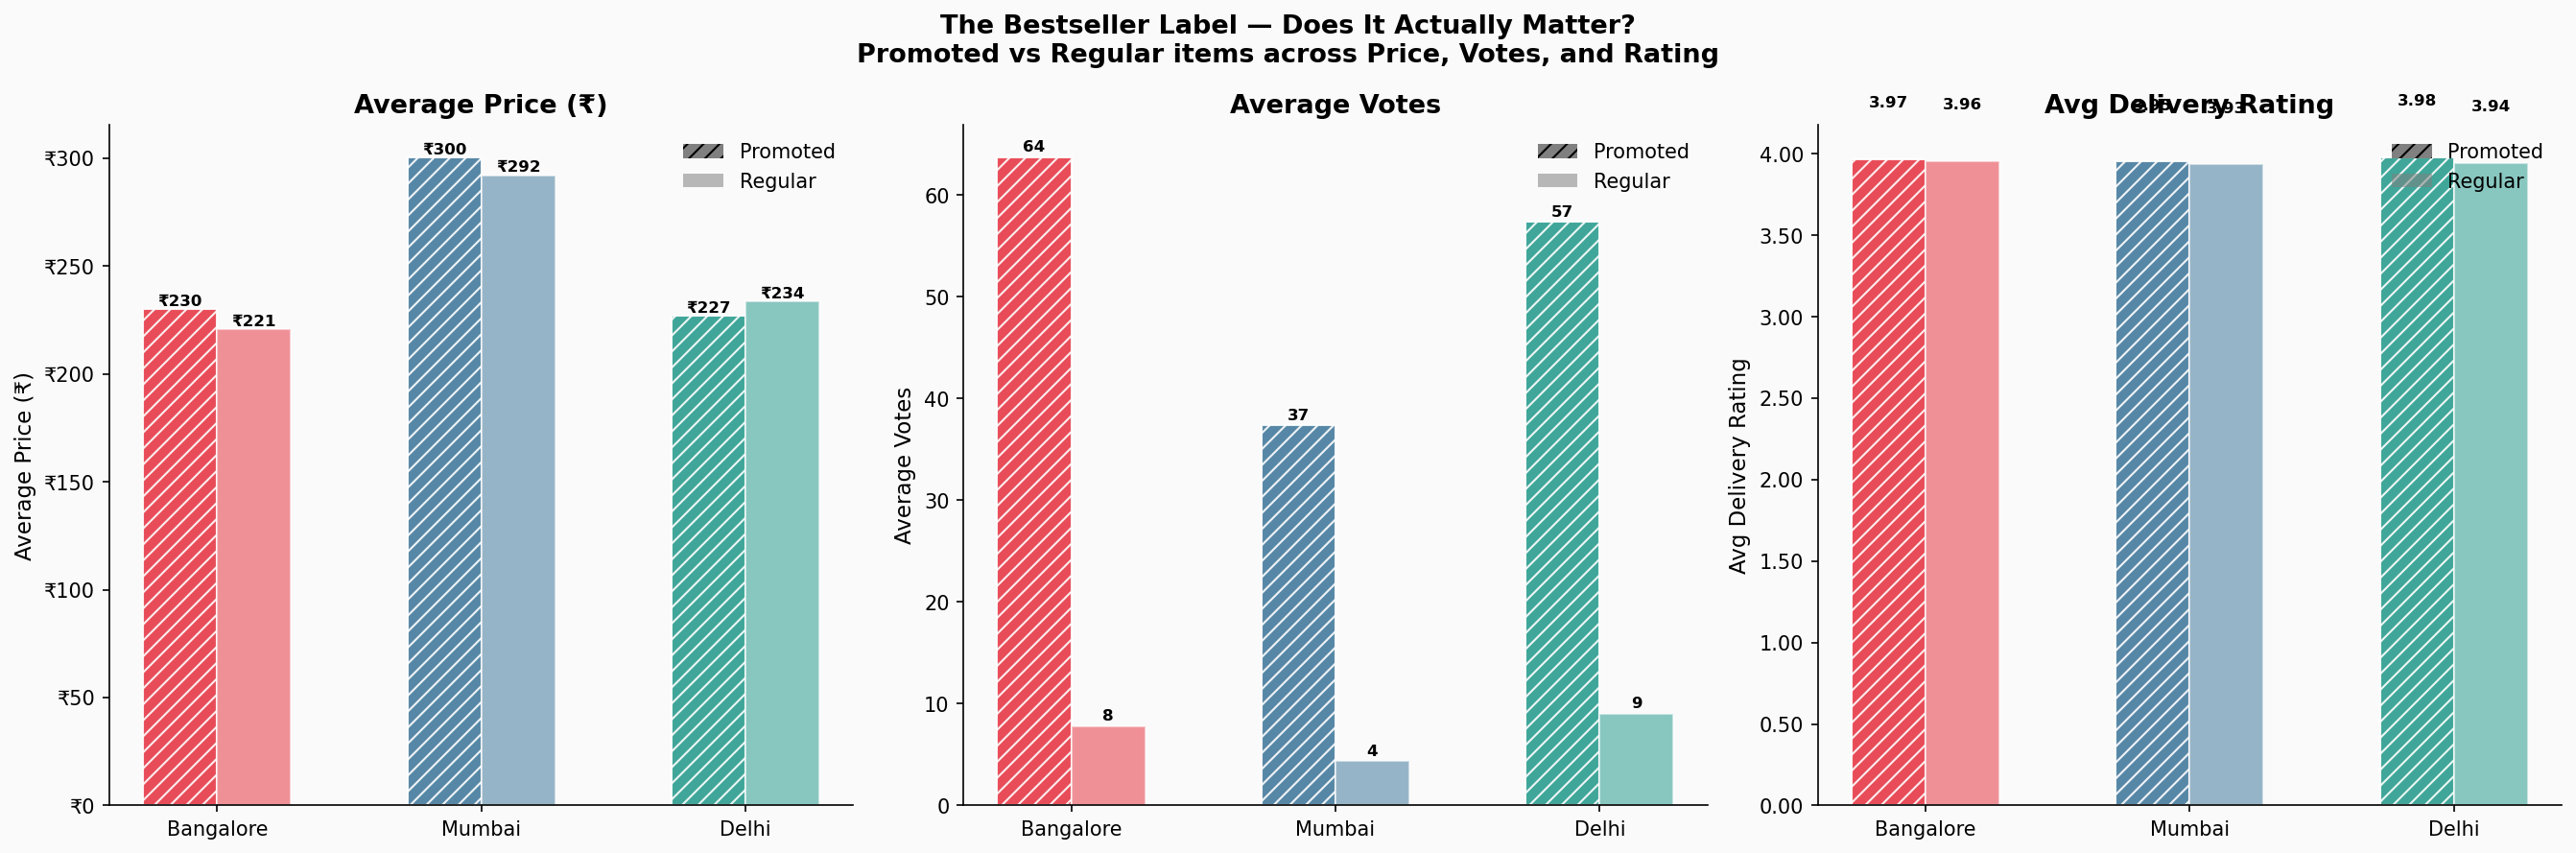

    ✓  Saved successfully to: zomato_analysis_outputs\BIZE_bestseller_impact.png


In [88]:
#  ANALYSIS E — Bestseller Label Impact
#  Hypothesis: The BESTSELLER/MUST TRY tag is a genuine commercial lever —
#  promoted items attract more votes (demand) AND command higher prices.
#  If the hypothesis holds, the tag is not cosmetic — it drives behaviour.
# ─────────────────────────────────────────────────────────────────────────────
print("  [E] Does the Bestseller label actually drive demand and pricing?")
 
item_summary = (
    df.groupby(['City', 'is_promoted'])
      .agg(avg_price  = ('Prices',          'mean'),
           avg_votes  = ('Votes',            'mean'),
           avg_rating = ('Delivery Rating',  'mean'),
           count      = ('Item Name',        'count'))
      .reset_index()
)
item_summary['label'] = item_summary['is_promoted'].map({1: "Promoted", 0: "Regular"})
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Bestseller Label — Does It Actually Matter?\n"
             "Promoted vs Regular items across Price, Votes, and Rating",
             fontsize=13, fontweight="bold")
 
x     = np.arange(len(CITIES))
width = 0.28
metrics_e = [
    ("avg_price",  "Average Price (₹)",   lambda v, _: f"₹{v:.0f}"),
    ("avg_votes",  "Average Votes",        lambda v, _: f"{v:.0f}"),
    ("avg_rating", "Avg Delivery Rating",  lambda v, _: f"{v:.2f}"),
]
 
for ax, (metric, ylabel, fmt) in zip(axes, metrics_e):
    for j, (ptype, hatch, shade) in enumerate([
        ("Promoted", "///", 0.90),
        ("Regular",  "",    0.55),
    ]):
        vals = []
        for c in CITIES:
            row = item_summary.loc[
                (item_summary['City'] == c) & (item_summary['label'] == ptype), metric
            ]
            vals.append(row.values[0] if len(row) else 0)
 
        bars = ax.bar(x + j * width, vals, width, hatch=hatch,
                      color=COLORS, alpha=shade, edgecolor="white", linewidth=1)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    fmt(val, None), ha="center", va="bottom",
                    fontsize=8, fontweight="bold")
 
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(CITIES)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt))
    ax.legend(handles=[
        mpatches.Patch(facecolor="gray", hatch="///", label="Promoted"),
        mpatches.Patch(facecolor="gray", alpha=0.55, label="Regular"),
    ], fontsize=10)
 
plt.tight_layout()
save(fig, "BIZE_bestseller_impact.png")

### Bestseller Label Analysis: Does It Actually Matter?

This analysis compares promoted (bestseller) items and regular items across three dimensions: pricing, customer engagement, and delivery rating.

---

#### 1. Pricing

- Promoted items are priced slightly higher than regular items in most cases.
- Price differences are small but consistent across cities.

**Observation:**  
Promoted items are not discounted. Instead, they tend to be positioned as high-demand or premium items.

---

#### 2. Popularity (Votes)

- Promoted items receive significantly higher vote counts compared to regular items across all cities.

**Observation:**  
Promotion is strongly associated with higher customer engagement and visibility.

---

#### 3. Delivery Ratings

- Average delivery ratings for promoted and regular items are nearly identical across all cities.

**Observation:**  
Promotion does not correspond to higher perceived quality, as measured by customer ratings.

---

#### 4. Key Insights

- Bestseller labels are strongly correlated with popularity, not necessarily with higher quality.
- Promoted items often command slightly higher prices, suggesting confidence in demand rather than discounting.
- The bestseller designation appears to function primarily as a signal of popularity and visibility rather than superior product quality.

---

  [F] City success DNA radar chart...


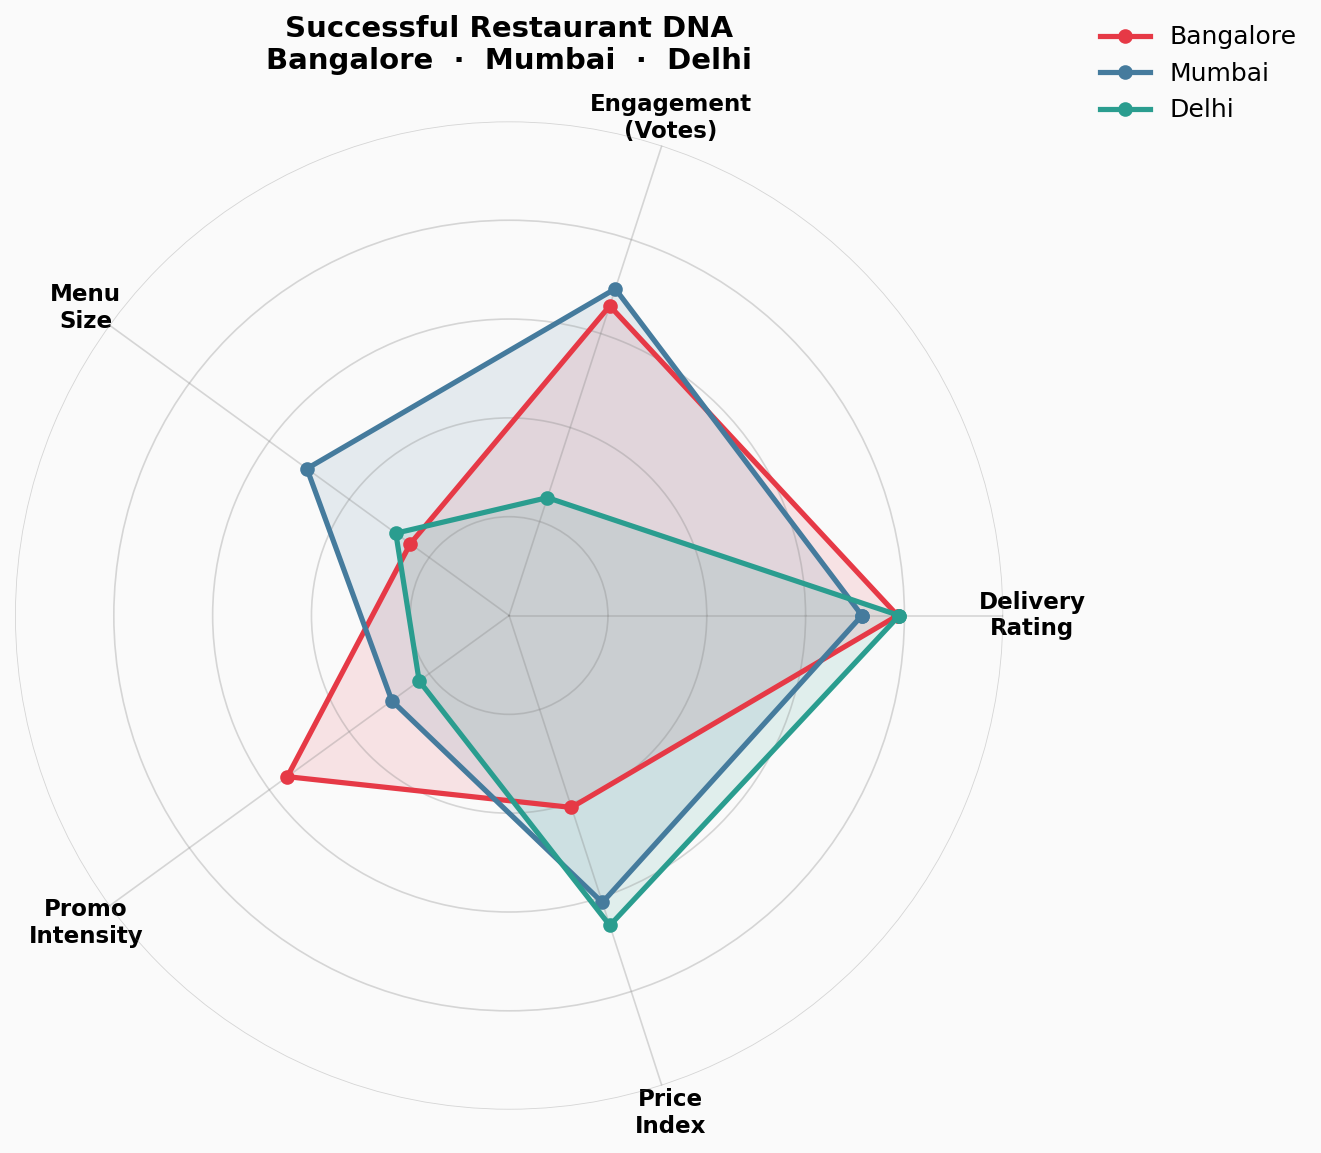

    ✓  Saved successfully to: zomato_analysis_outputs\BIZF_city_radar.png

  ✅  All business analyses complete.


In [89]:
#  ANALYSIS F — City DNA Radar Chart
#  This is the synthesis visual. It does not test one hypothesis —
#  it plots the full multi-dimensional signature of successful restaurants
#  in each city simultaneously. The shape of each city's polygon IS the answer
#  to our central research question.
# ─────────────────────────────────────────────────────────────────────────────
print("  [F] City success DNA radar chart...")
 
dimensions = {
    "Delivery\nRating"   : "delivery_rating",
    "Engagement\n(Votes)": "engagement",
    "Menu\nSize"         : "total_items",
    "Promo\nIntensity"   : "promo_ratio",
    "Price\nIndex"       : "median_price",
}
dim_labels = list(dimensions.keys())
N      = len(dim_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
 
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("#FAFAFA")
 
for city in CITIES:
    sdf    = rest[(rest['City'] == city) & (rest['is_successful'] == 1)]
    scores = []
    for _, col in dimensions.items():
        g_max = rest[col].quantile(0.95)
        g_min = rest[col].quantile(0.05)
        norm  = (sdf[col].mean() - g_min) / (g_max - g_min + 1e-9)
        scores.append(float(np.clip(norm, 0, 1)))
    scores += scores[:1]
    ax.plot(angles, scores, "o-", linewidth=2.5,
            color=CITY_COLORS[city], label=city)
    ax.fill(angles, scores, alpha=0.12, color=CITY_COLORS[city])
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=11, fontweight="bold")
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.grid(color="gray", alpha=0.3)
ax.spines["polar"].set_visible(False)
ax.set_title("Successful Restaurant DNA\nBangalore  ·  Mumbai  ·  Delhi",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=12)
 
plt.tight_layout()
save(fig, "BIZF_city_radar.png")
 
print(f"\n  ✅  All business analyses complete.")

### Successful Restaurant DNA — Comparative Analysis

This radar chart compares the strategic profiles of successful restaurants across cities based on five dimensions: Delivery Rating, Engagement, Menu Size, Promotion Intensity, and Price Index.

---

#### Mumbai
- Highest engagement levels among successful restaurants.
- Larger menus indicate a variety-driven strategy.
- Balanced pricing and strong delivery performance.

**Conclusion:** Mumbai’s successful restaurants combine visibility, variety, and quality.

---

#### Bangalore
- Highest promotional intensity among the three cities.
- Strong delivery performance and competitive pricing.
- Moderate engagement and menu size.

**Conclusion:** Bangalore success leans on promotions and service quality.

---

#### Delhi
- Highest price index, indicating premium positioning.
- Smaller menus but strong delivery ratings.
- Lower engagement compared to other cities.

**Conclusion:** Delhi’s successful restaurants emphasize premium positioning and focused menus.

---

#### Overall Insights
- Delivery quality is a consistent strength across all cities.
- There is no single formula for success; each city follows a distinct strategy:
  - Mumbai → Scale & engagement
  - Bangalore → Promotions & experience
  - Delhi → Premium & efficiency

#  CHAPTER 5 — KEY FINDINGS

In [92]:
for city in CITIES:
    cdf = rest[rest['City'] == city]
    sdf = cdf[cdf['is_successful'] == 1]
    fdf = cdf[cdf['is_successful'] == 0]
 
    price_premium = sdf['median_price'].median() - fdf['median_price'].median()
    top_cuisine   = (cdf.groupby('Cuisine')['is_successful']
                        .mean().sort_values(ascending=False).index[0])
    promo_s = sdf['promo_ratio'].mean() * 100
    promo_f = fdf['promo_ratio'].mean() * 100
    promo_insight = (
        "Restraint signals quality — winners promote LESS"
        if promo_s < promo_f
        else "Promotion drives demand — winners promote MORE"
    )
 
    print(f"\n  ── {city.upper()} " + "─"*50)
    print(f"     Success rate              : "
          f"{sdf.shape[0]}/{cdf.shape[0]} restaurants ({sdf.shape[0]/cdf.shape[0]*100:.0f}%)")
    print(f"     Avg delivery rating       : "
          f"{sdf['delivery_rating'].mean():.2f} (successful) vs "
          f"{fdf['delivery_rating'].mean():.2f} (unsuccessful)")
    print(f"     Price premium of success  : ₹{price_premium:+.0f}")
    print(f"     Top cuisine by success    : {top_cuisine}")
    print(f"     Promotion strategy        : "
          f"{promo_s:.1f}% (success) vs {promo_f:.1f}% (others) → {promo_insight}")


  ── BANGALORE ──────────────────────────────────────────────────
     Success rate              : 18/86 restaurants (21%)
     Avg delivery rating       : 4.17 (successful) vs 3.91 (unsuccessful)
     Price premium of success  : ₹+51
     Top cuisine by success    : Rajasthani
     Promotion strategy        : 20.8% (success) vs 18.7% (others) → Promotion drives demand — winners promote MORE

  ── MUMBAI ──────────────────────────────────────────────────
     Success rate              : 19/80 restaurants (24%)
     Avg delivery rating       : 4.11 (successful) vs 3.91 (unsuccessful)
     Price premium of success  : ₹+1
     Top cuisine by success    : Mexican
     Promotion strategy        : 13.4% (success) vs 16.8% (others) → Restraint signals quality — winners promote LESS

  ── DELHI ──────────────────────────────────────────────────
     Success rate              : 4/24 restaurants (17%)
     Avg delivery rating       : 4.18 (successful) vs 3.96 (unsuccessful)
     Price premium o

#  CHAPTER 6 — EXPORT FOR POWER BI

In [95]:
rest.to_csv(f"{OUT_DIR}/powerbi_restaurants.csv", index=False)
print(f"  ✓  powerbi_restaurants.csv    ({rest.shape[0]:,} rows)")
 
city_cuisine = (
    rest.groupby(['City', 'Cuisine'])
        .agg(restaurants      = ('Restaurant Name', 'count'),
             success_rate     = ('is_successful',   'mean'),
             avg_price        = ('median_price',    'mean'),
             avg_delivery_rtg = ('delivery_rating', 'mean'),
             avg_items        = ('total_items',     'mean'),
             avg_promo_ratio  = ('promo_ratio',     'mean'))
        .query("restaurants >= 3")
        .reset_index()
)
city_cuisine.to_csv(f"{OUT_DIR}/powerbi_city_cuisine.csv", index=False)
print(f"  ✓  powerbi_city_cuisine.csv   ({city_cuisine.shape[0]:,} rows)")
 
items_export = df[['Restaurant Name', 'City', 'Cuisine', 'Item Name',
                   'Prices', 'Delivery Rating', 'Votes',
                   'is_promoted', 'Best Seller']].copy()
items_export.to_csv(f"{OUT_DIR}/powerbi_items.csv", index=False)
print(f"  ✓  powerbi_items.csv          ({items_export.shape[0]:,} rows)")
 
print(f"\n  All outputs saved to: {OUT_DIR}")
print("\n" + "="*70)
print("  ANALYSIS COMPLETE")
print("="*70 + "\n")

  ✓  powerbi_restaurants.csv    (190 rows)
  ✓  powerbi_city_cuisine.csv   (20 rows)
  ✓  powerbi_items.csv          (22,547 rows)

  All outputs saved to: zomato_analysis_outputs

  ANALYSIS COMPLETE

